# Report final figures

All figures for the Chapter 8 EDA report section (self-contained `chapter_08` package).

**Filter:** `recency_in_months == 0` only (current-month impacts).
**Years:** 2005–2025.
**Outputs:** `results/figures/` (PNGs) and `results/tables/` (CSVs).

Update Overleaf numbers from `results/tables/report_final_stats.csv`.


In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Arc as MplArc, Patch
from IPython.display import Image, display
PACKAGE_ROOT = Path("..").resolve()
if not (PACKAGE_ROOT / "data").exists():
    PACKAGE_ROOT = Path(".").resolve()
    if PACKAGE_ROOT.name == "notebooks":
        PACKAGE_ROOT = PACKAGE_ROOT.parent

Y_PATH = PACKAGE_ROOT / "data" / "input" / "impacts_nuts3.csv"
NUTS_GEOJSON = PACKAGE_ROOT / "data" / "input" / "nuts_nl_simplified.geojson"
KNMI_DEFICIT_PATH = PACKAGE_ROOT / "data" / "input" / "droogte_data_knmi.txt"
FIG_DIR = PACKAGE_ROOT / "results" / "figures"
TABLE_DIR = PACKAGE_ROOT / "results" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

YEAR_MIN, YEAR_MAX = 2005, 2025
PERIOD_EARLY = list(range(2005, 2018))
PERIOD_LATE = list(range(2018, 2026))
RECENCY_FILTER = 0
COUNT_COL = "mention_weight"
FIG_DPI = 150
N_DISCRETE_BINS = 6
DISCRETE_CMAP = "YlOrRd"
EMPTY_REGION_COLOR = "#ebeff5"
KNMI_DEFICIT_BAR_COLOR = "#377eb8"
TOP_N_EDGES_PLOT = 13  # include Wildfire Occurrence -- Wildfire Risk Increase

CLASSIFICATION_ORDER = [
    "Crop Failure & Yield Reduction",
    "Livestock Stress & Mortality",
    "Irrigation Shortage",
    "Groundwater Depletion",
    "Reservoir & Surface Water Shortage",
    "Water Use Restrictions",
    "Hydropower Reduction",
    "Thermal/Nuclear Cooling Constraints",
    "Industrial Water Shortages",
    "Inland Waterway Disruption",
    "Freshwater Ecosystem Degradation",
    "Forest Dieback & Vegetation Stress",
    "Wetland Loss",
    "Wildfire Occurrence",
    "Wildfire Risk Increase",
    "Heat & Air Quality Health Impacts",
    "Water Supply & Sanitation Issues",
    "Agricultural Economic Loss",
    "Broader Economic Disruption",
    "Social Impacts",
]

CLASSIFICATION_THEME: dict[str, str] = {
    "Crop Failure & Yield Reduction": "agriculture",
    "Livestock Stress & Mortality": "agriculture",
    "Irrigation Shortage": "agriculture",
    "Agricultural Economic Loss": "agriculture",
    "Groundwater Depletion": "water",
    "Reservoir & Surface Water Shortage": "water",
    "Water Use Restrictions": "water",
    "Water Supply & Sanitation Issues": "water",
    "Hydropower Reduction": "water",
    "Thermal/Nuclear Cooling Constraints": "water",
    "Industrial Water Shortages": "water",
    "Inland Waterway Disruption": "water",
    "Wildfire Occurrence": "fire_heat",
    "Wildfire Risk Increase": "fire_heat",
    "Heat & Air Quality Health Impacts": "fire_heat",
    "Freshwater Ecosystem Degradation": "ecosystem",
    "Forest Dieback & Vegetation Stress": "ecosystem",
    "Wetland Loss": "ecosystem",
    "Broader Economic Disruption": "economy",
    "Social Impacts": "social",
}

THEME_ORDER = ["agriculture", "water", "ecosystem", "fire_heat", "economy", "social"]
THEME_LABELS = {
    "agriculture": "Agriculture",
    "water": "Water",
    "ecosystem": "Ecosystem",
    "fire_heat": "Fire & heat",
    "economy": "Economy",
    "social": "Social",
}
THEME_COLOR = {
    "agriculture": "#2ca02c",
    "water": "#1f77b4",
    "ecosystem": "#8c564b",
    "fire_heat": "#d62728",
    "economy": "#9467bd",
    "social": "#ff7f0e",
}

SHORT_LABEL = {
    "Crop Failure & Yield Reduction": "Crop failure",
    "Livestock Stress & Mortality": "Livestock",
    "Irrigation Shortage": "Irrigation",
    "Groundwater Depletion": "Groundwater",
    "Reservoir & Surface Water Shortage": "Reservoir/SW",
    "Water Use Restrictions": "Use restrictions",
    "Hydropower Reduction": "Hydropower",
    "Thermal/Nuclear Cooling Constraints": "Thermal cooling",
    "Industrial Water Shortages": "Industrial water",
    "Inland Waterway Disruption": "Waterways",
    "Freshwater Ecosystem Degradation": "Freshwater eco",
    "Forest Dieback & Vegetation Stress": "Forest dieback",
    "Wetland Loss": "Wetlands",
    "Wildfire Occurrence": "Wildfire",
    "Wildfire Risk Increase": "Wildfire risk",
    "Heat & Air Quality Health Impacts": "Heat/AQ health",
    "Water Supply & Sanitation Issues": "Water supply",
    "Agricultural Economic Loss": "Agri economic",
    "Broader Economic Disruption": "Broader economy",
    "Social Impacts": "Social",
}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = FIG_DPI

print("All figures use recency_in_months == 0; update Overleaf from report_final_stats.csv")
print(f"Data: {Y_PATH.exists()}  {Y_PATH}")
print(f"Figures: {FIG_DIR}")
print(f"Tables:  {TABLE_DIR}")


All figures use recency_in_months == 0; update Overleaf from report_final_stats.csv
Data: True  C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\08_exploratory_data_analysis\data\input\impacts_nuts3.csv
Figures: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\08_exploratory_data_analysis\results\figures
Tables:  C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\08_exploratory_data_analysis\results\tables


## Helpers

In [2]:
def save_and_show(fig, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved {path.name}")


def load_knmi_sep30_deficit(data_path: str | Path) -> pd.DataFrame:
    raw = pd.read_csv(
        data_path, comment="#", sep=r"\s+", header=None, usecols=[0, 1],
        names=["date_code", "deficit_mm"], engine="python",
    )
    raw["deficit_mm"] = pd.to_numeric(raw["deficit_mm"], errors="coerce")
    raw["date"] = pd.to_datetime(raw["date_code"].astype(str), format="%Y%m%d", errors="coerce")
    raw = raw.dropna(subset=["date", "deficit_mm"]).sort_values("date")
    raw = raw.drop_duplicates(subset="date", keep="last")
    season = raw.loc[raw["date"].dt.month.between(4, 9)].copy()
    rows = []
    for year, group in season.groupby(season["date"].dt.year):
        mask = (group["date"].dt.month == 9) & (group["date"].dt.day == 30)
        if mask.any():
            deficit_mm = float(group.loc[mask, "deficit_mm"].iloc[0])
        elif not group.empty:
            deficit_mm = float(group.sort_values("date")["deficit_mm"].iloc[-1])
        else:
            continue
        rows.append({"year": int(year), "deficit_mm": deficit_mm})
    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def _fmt_count(value: float) -> str:
    return f"{value:.0f}" if value >= 10 else f"{value:.1f}"


def discrete_bin_edges(values: np.ndarray, n_bins: int = N_DISCRETE_BINS, *, include_zero: bool = False) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    sample = arr if include_zero else arr[arr > 0]
    if sample.size == 0:
        return np.array([0.0, 1.0])
    qs = np.linspace(0, 100, n_bins + 1)
    edges = np.unique(np.percentile(sample, qs))
    if include_zero and edges[0] > 0:
        edges = np.concatenate([[0.0], edges])
    if edges.size < 2:
        return np.array([0.0, max(float(sample.max()), 1.0)])
    return edges


def make_discrete_cmap(n_colors: int, base: str = DISCRETE_CMAP) -> ListedColormap:
    colors = plt.get_cmap(base)(np.linspace(0.25, 1.0, n_colors))
    return ListedColormap(colors)


def bin_interval_label(lo: float, hi: float, *, last: bool = False) -> str:
    if last and lo < hi:
        return f"> {_fmt_count(lo)}"
    if np.isclose(lo, hi):
        return _fmt_count(lo)
    return f"{_fmt_count(lo)}-{_fmt_count(hi)}"


def add_discrete_legend(ax, edges, cmap, *, title: str = "Weighted count") -> None:
    patches = []
    for i in range(cmap.N):
        lo, hi = edges[i], edges[i + 1]
        patches.append(
            Patch(facecolor=cmap(i), edgecolor="0.45",
                  label=bin_interval_label(lo, hi, last=(i == cmap.N - 1)))
        )
    ax.legend(handles=patches, title=title, loc="lower left", fontsize=7, framealpha=0.92)


def plot_choropleth(gdf, counts_df, id_col, value_col, title, *, legend_title="Weighted count", save_path=None):
    map_df = gdf.merge(counts_df, left_on="NUTS_ID", right_on=id_col, how="left")
    map_df[value_col] = map_df[value_col].fillna(0)
    fig, ax = plt.subplots(figsize=(9, 10))
    zero_df = map_df[map_df[value_col] <= 0]
    nonzero_df = map_df[map_df[value_col] > 0]
    if not zero_df.empty:
        zero_df.plot(ax=ax, color=EMPTY_REGION_COLOR, edgecolor="0.55", linewidth=0.35)
    if not nonzero_df.empty:
        edges = discrete_bin_edges(nonzero_df[value_col].to_numpy())
        discrete_cmap = make_discrete_cmap(len(edges) - 1)
        norm = BoundaryNorm(edges, ncolors=discrete_cmap.N)
        nonzero_df.plot(column=value_col, cmap=discrete_cmap, norm=norm, legend=False,
                        ax=ax, edgecolor="0.55", linewidth=0.35)
        add_discrete_legend(ax, edges, discrete_cmap, title=legend_title)
    for _, row in map_df.iterrows():
        c = row.geometry.centroid
        ax.annotate(row["NUTS_ID"], xy=(c.x, c.y), ha="center", va="center", fontsize=5.5, color="0.25")
    for _, row in nonzero_df.iterrows():
        c = row.geometry.centroid
        ax.annotate(_fmt_count(row[value_col]), xy=(c.x, c.y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=6, fontweight="bold", color="0.1")
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()
    if save_path is not None:
        save_and_show(fig, Path(save_path))
    else:
        display(fig)
        plt.close(fig)


def edge_boldness_bins(weights: np.ndarray):
    w = np.asarray(weights, dtype=float)
    if w.size == 0:
        return np.array([], dtype=int), []
    t1, t2 = np.quantile(w, [1 / 3, 2 / 3])
    cuts = sorted({float(w.min() - 1e-9), float(t1), float(t2), float(w.max() + 1e-9)})
    while len(cuts) < 4:
        cuts.insert(-1, cuts[-2] + 1e-6)
    levels = np.clip(np.digitize(w, cuts[1:-1], right=True), 0, 2)
    linewidths = [2.0, 4.5, 8.0]
    labels = ["Low co-occurrence", "Medium co-occurrence", "High co-occurrence"]
    legend_specs = []
    for lvl in range(3):
        mask = levels == lvl
        if not mask.any():
            continue
        lo, hi = float(w[mask].min()), float(w[mask].max())
        rng = f"{lo:.0f} articles" if lo == hi else f"{lo:.0f}-{hi:.0f} articles"
        legend_specs.append((f"{labels[lvl]} ({rng})", linewidths[lvl], "0.35"))
    return levels, legend_specs


def cooccurrence_legends(ax, G, *, theme_loc="upper left", bold_loc="lower left"):
    weights = np.array([G[u][v]["weight"] for u, v in G.edges()], dtype=float)
    _, bold_specs = edge_boldness_bins(weights)
    themes_present = sorted({G.nodes[n]["theme"] for n in G.nodes()}, key=lambda t: list(THEME_COLOR).index(t))
    theme_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=THEME_COLOR[t], markersize=11, label=t)
        for t in themes_present
    ]
    bold_handles = [Line2D([0], [0], color=c, lw=lw, label=lab) for lab, lw, c in bold_specs]
    leg1 = ax.legend(handles=theme_handles, title="Theme", loc=theme_loc, fontsize=9, framealpha=0.95)
    ax.add_artist(leg1)
    ax.legend(handles=bold_handles, title="Link strength (line boldness)", loc=bold_loc, fontsize=9, framealpha=0.95)


def build_cooc_graph(edges: pd.DataFrame, counts: pd.Series, top_n: int = TOP_N_EDGES_PLOT) -> nx.Graph:
    plot_edges = edges.sort_values("weight", ascending=False).head(top_n).copy()
    G = nx.Graph()
    for cls in CLASSIFICATION_ORDER:
        if int(counts.get(cls, 0)) <= 0:
            continue
        G.add_node(cls, count=int(counts.get(cls, 0)), theme=CLASSIFICATION_THEME[cls])
    for _, row in plot_edges.iterrows():
        if row["source"] in G and row["target"] in G:
            G.add_edge(row["source"], row["target"], weight=int(row["weight"]))
    G.remove_nodes_from(list(nx.isolates(G)))
    return G


def draw_theme_circular(G: nx.Graph, save_path: Path, title: str) -> None:
    theme_order = list(THEME_COLOR.keys())
    nodes = sorted(G.nodes(), key=lambda n: (theme_order.index(G.nodes[n]["theme"]), -G.nodes[n]["count"]))
    n = len(nodes)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False) + np.pi / 2
    pos = {node: (np.cos(a), np.sin(a)) for node, a in zip(nodes, angles)}
    fig, ax = plt.subplots(figsize=(11, 11), layout="constrained")
    theme_nodes = defaultdict(list)
    for node, a in zip(nodes, angles):
        theme_nodes[G.nodes[node]["theme"]].append(a)
    for theme, angs in theme_nodes.items():
        a0, a1 = min(angs) - 0.08, max(angs) + 0.08
        ax.add_patch(mpatches.Wedge(
            (0, 0), 1.35, np.degrees(a0), np.degrees(a1), width=0.14,
            facecolor=THEME_COLOR[theme], alpha=0.18, edgecolor="none", zorder=0,
        ))
    weights = np.array([G[u][v]["weight"] for u, v in G.edges()], dtype=float)
    levels, _ = edge_boldness_bins(weights)
    lw_map = {0: 2.0, 1: 4.5, 2: 8.0}
    for (u, v), lv in zip(G.edges(), levels):
        ax.annotate("", xy=pos[v], xytext=pos[u],
                    arrowprops=dict(arrowstyle="-", color="0.35", lw=lw_map[int(lv)],
                                    alpha=0.75, connectionstyle="arc3,rad=0.12"), zorder=1)
    max_c = max(G.nodes[x]["count"] for x in nodes)
    sizes = [500 + 2400 * (G.nodes[node]["count"] / max_c) for node in nodes]
    colors = [THEME_COLOR[G.nodes[node]["theme"]] for node in nodes]
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nodes, node_size=sizes,
                           node_color=colors, edgecolors="0.2", linewidths=0.8)
    for node, (x, y) in pos.items():
        ax.text(x * 1.26, y * 1.26, SHORT_LABEL.get(node, node),
                fontsize=11, fontweight="bold", ha="center", va="center")
    cooccurrence_legends(ax, G)
    ax.set_title(title, fontsize=13)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    save_and_show(fig, Path(save_path))


def draw_arc_diagram(G: nx.Graph, save_path: Path, title: str) -> None:
    theme_order = list(THEME_COLOR.keys())
    nodes = sorted(G.nodes(), key=lambda n: (theme_order.index(G.nodes[n]["theme"]), -G.nodes[n]["count"]))
    n = len(nodes)
    x_coords = np.linspace(0, 1, n)
    pos = {node: (x, 0.0) for node, x in zip(nodes, x_coords)}
    fig, ax = plt.subplots(figsize=(14, 6.8), layout="constrained")
    edges = [(u, v, G[u][v]["weight"]) for u, v in G.edges()]
    weights = np.array([w for _, _, w in edges], dtype=float)
    levels, _ = edge_boldness_bins(weights)
    lw_map = {0: 2.0, 1: 4.5, 2: 8.0}
    for idx in np.argsort(weights):
        u, v, w = edges[idx]
        lv = int(levels[idx])
        x0, x1 = pos[u][0], pos[v][0]
        if x0 > x1:
            x0, x1 = x1, x0
        width = x1 - x0
        height = max(width * 1.15, 0.15)
        ax.add_patch(MplArc(((x0 + x1) / 2, 0), width, height, theta1=0, theta2=180,
                            color="0.35", lw=lw_map[lv], alpha=0.8, fill=False, zorder=1 + lv))
    counts_arr = np.array([G.nodes[n]["count"] for n in nodes])
    sizes = 180 + 1100 * (counts_arr / max(counts_arr.max(), 1))
    colors = [THEME_COLOR[G.nodes[n]["theme"]] for n in nodes]
    ax.scatter(x_coords, np.zeros(n), s=sizes, c=colors, edgecolors="0.2", linewidths=0.8, zorder=4)
    for i, node in enumerate(nodes):
        ax.text(x_coords[i], -0.1, SHORT_LABEL.get(node, node),
                rotation=40, ha="right", va="top", fontsize=11, fontweight="bold")
    cooccurrence_legends(ax, G, theme_loc="upper left", bold_loc="upper right")
    ax.set_title(title, fontsize=13)
    ax.set_xlim(-0.05, 1.05)
    ymax = max(((abs(pos[u][0] - pos[v][0]) * 1.15) / 2) for u, v in G.edges()) if G.number_of_edges() else 0.5
    ax.set_ylim(-0.65, ymax + 0.2)
    ax.set_axis_off()
    save_and_show(fig, Path(save_path))


print("Helpers ready")


Helpers ready


## 1. Load and filter (recency = 0)

In [3]:
impacts_raw = pd.read_csv(Y_PATH, parse_dates=["publication_date"], low_memory=False)
impacts_raw["year"] = impacts_raw["publication_date"].dt.year
impacts_raw["month"] = impacts_raw["publication_date"].dt.month
impacts_raw["year_month"] = impacts_raw["publication_date"].dt.to_period("M").astype(str)

df = impacts_raw.loc[
    (impacts_raw["nuts_level"] == "nuts3")
    & (impacts_raw["recency_in_months"].fillna(-1).astype(int) == RECENCY_FILTER)
].copy()
df_years = df.loc[df["year"].between(YEAR_MIN, YEAR_MAX)].copy()

gdf_all = gpd.read_file(NUTS_GEOJSON)
gdf3 = gdf_all.loc[gdf_all["LEVL_CODE"] == 3, ["NUTS_ID", "NAME_LATN", "geometry"]].copy()

print(f"Full corpus: {len(impacts_raw):,}")
print(f"NUTS-3 + recency=0: {len(df):,} | 2005-2025: {len(df_years):,}")
print(f"Articles: {df['id'].nunique():,}")


Full corpus: 48,444
NUTS-3 + recency=0: 16,082 | 2005-2025: 15,588
Articles: 4,369


## 2. Temporal — yearly volume

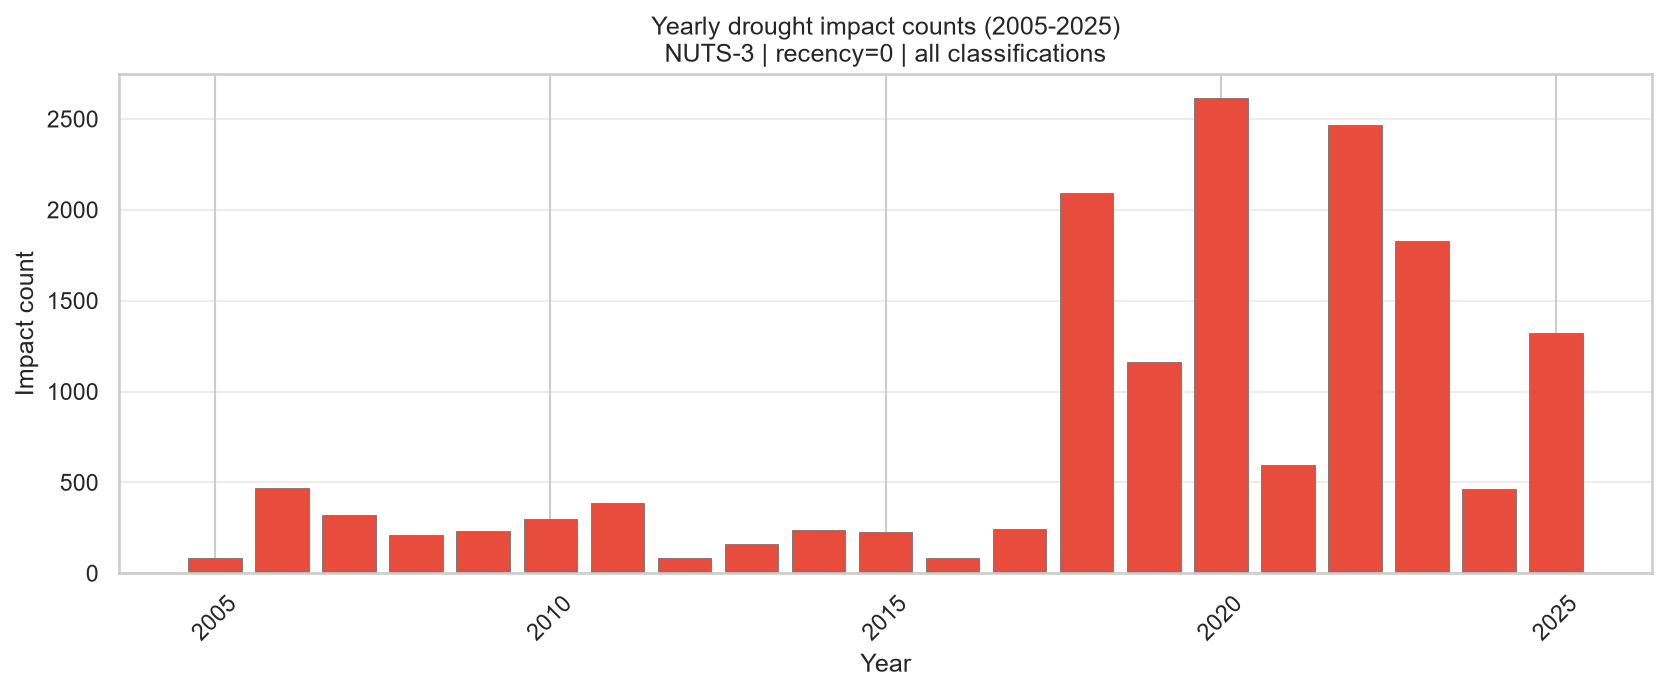

Saved fig_yearly_volume.png
2017->244  2018->2095


In [4]:
yearly = (
    df_years.groupby("year").size()
    .reindex(range(YEAR_MIN, YEAR_MAX + 1), fill_value=0)
    .astype(int)
)
early_total = int(yearly.reindex(PERIOD_EARLY).fillna(0).sum())
late_total = int(yearly.reindex(PERIOD_LATE).fillna(0).sum())
early_mean = early_total / len(PERIOD_EARLY)
late_mean = late_total / len(PERIOD_LATE)
jump_2017 = int(yearly.get(2017, 0))
jump_2018 = int(yearly.get(2018, 0))

fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
ax.bar(yearly.index.astype(int), yearly.values, color="#e74c3c", edgecolor="0.45", linewidth=0.4, width=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Impact count")
ax.set_title("Yearly drought impact counts (2005-2025)\nNUTS-3 | recency=0 | all classifications")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.35)
save_and_show(fig, FIG_DIR / "fig_yearly_volume.png")
print(f"2017->{jump_2017}  2018->{jump_2018}")


## 3. Temporal — meteo comparison (normalized dual periods)

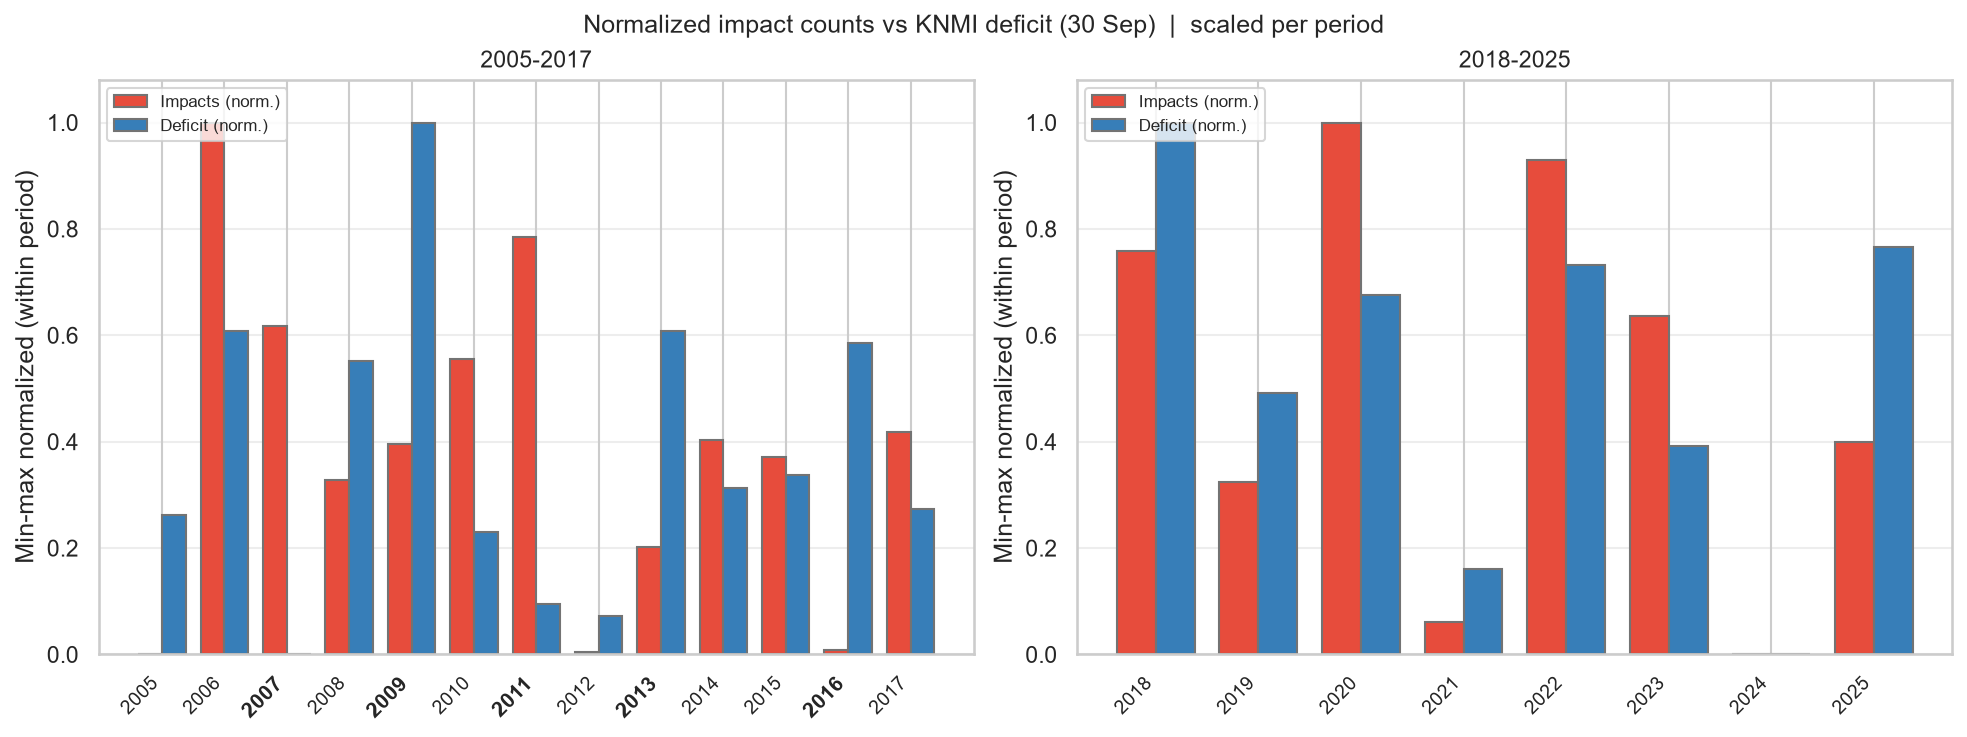

Saved fig_meteo_comparison.png
Divergent years (|Δ_norm| >= 0.4):


,period,year,delta_norm,higher,impact_norm,deficit_norm
0,2005-2017,2007,0.618,impacts,0.618,0.000
1,2005-2017,2009,0.605,deficit,0.395,1.000
2,2005-2017,2011,0.689,impacts,0.784,0.095
3,2005-2017,2013,0.405,deficit,0.203,0.608
4,2005-2017,2016,0.578,deficit,0.008,0.585


In [5]:
knmi = load_knmi_sep30_deficit(KNMI_DEFICIT_PATH).set_index("year")["deficit_mm"]
impacts_y = yearly.astype(float)
years_common = sorted(set(impacts_y.index) & set(knmi.index) & set(range(YEAR_MIN, YEAR_MAX + 1)))
merged = pd.DataFrame({
    "year": years_common,
    "impact_count": [impacts_y[y] for y in years_common],
    "deficit_mm": [knmi[y] for y in years_common],
}).set_index("year")

DIVERGENCE_THRESHOLD = 0.40  # |norm impact - norm deficit| within period


def _minmax(s: pd.Series) -> pd.Series:
    lo, hi = float(s.min()), float(s.max())
    if hi <= lo:
        return s * 0.0
    return (s - lo) / (hi - lo)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")
divergent_rows = []
for ax, years, label in (
    (axes[0], PERIOD_EARLY, "2005-2017"),
    (axes[1], PERIOD_LATE, "2018-2025"),
):
    yrs = [y for y in years if y in merged.index]
    sub = merged.loc[yrs]
    imp_n = _minmax(sub["impact_count"])
    def_n = _minmax(sub["deficit_mm"])
    delta = (imp_n - def_n).abs()
    x = np.arange(len(yrs))
    w = 0.38
    ax.bar(x - w / 2, imp_n, width=w, color="#e74c3c", edgecolor="0.45", label="Impacts (norm.)")
    ax.bar(x + w / 2, def_n, width=w, color=KNMI_DEFICIT_BAR_COLOR, edgecolor="0.45", label="Deficit (norm.)")
    ax.set_xticks(x)
    labels = []
    weights = []
    for y in yrs:
        d = float(delta.loc[y])
        labels.append(str(y))
        weights.append("bold" if d >= DIVERGENCE_THRESHOLD else "normal")
        if d >= DIVERGENCE_THRESHOLD:
            higher = "impacts" if float(imp_n.loc[y]) > float(def_n.loc[y]) else "deficit"
            divergent_rows.append({
                "period": label,
                "year": int(y),
                "delta_norm": round(d, 3),
                "higher": higher,
                "impact_norm": round(float(imp_n.loc[y]), 3),
                "deficit_norm": round(float(def_n.loc[y]), 3),
            })
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    for tick, weight in zip(ax.get_xticklabels(), weights):
        tick.set_fontweight(weight)
        if weight == "bold":
            tick.set_fontsize(10)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Min-max normalized (within period)")
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, axis="y", alpha=0.35)

fig.suptitle("Normalized impact counts vs KNMI deficit (30 Sep)  |  scaled per period", fontsize=12)
save_and_show(fig, FIG_DIR / "fig_meteo_comparison.png")

meteo_divergent = pd.DataFrame(divergent_rows)
print(f"Divergent years (|Δ_norm| >= {DIVERGENCE_THRESHOLD}):")
display(meteo_divergent)


## 4. Temporal — monthly seasonality

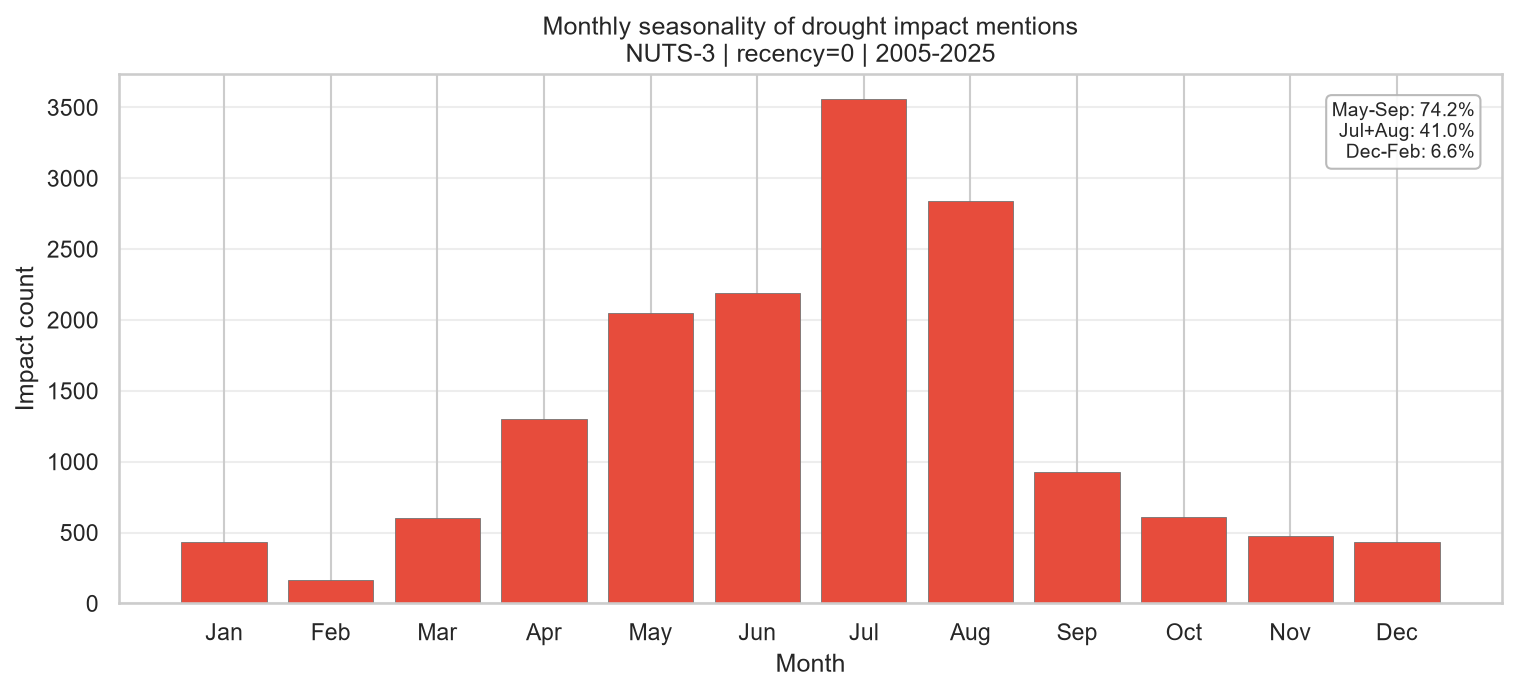

Saved fig_monthly_seasonality.png
May-Sep 74.2% | Jul+Aug 41.0% | winter 6.6%


In [6]:
monthly = df_years["month"].value_counts().reindex(range(1, 13), fill_value=0).astype(int)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
summer = int(monthly.loc[5:9].sum())
jul_aug = int(monthly.loc[[7, 8]].sum())
winter = int(monthly.loc[[12, 1, 2]].sum())
total_m = int(monthly.sum())
summer_pct = 100 * summer / total_m
jul_aug_pct = 100 * jul_aug / total_m
winter_pct = 100 * winter / total_m

fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.bar(month_names, monthly.values, color="#e74c3c", edgecolor="0.45", linewidth=0.4)
ax.set_xlabel("Month")
ax.set_ylabel("Impact count")
ax.set_title("Monthly seasonality of drought impact mentions\nNUTS-3 | recency=0 | 2005-2025")
ax.grid(True, axis="y", alpha=0.35)
ax.text(0.98, 0.95,
        f"May-Sep: {summer_pct:.1f}%\nJul+Aug: {jul_aug_pct:.1f}%\nDec-Feb: {winter_pct:.1f}%",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="0.7"))
save_and_show(fig, FIG_DIR / "fig_monthly_seasonality.png")
print(f"May-Sep {summer_pct:.1f}% | Jul+Aug {jul_aug_pct:.1f}% | winter {winter_pct:.1f}%")


## 5. Spatial — NUTS-3 choropleth

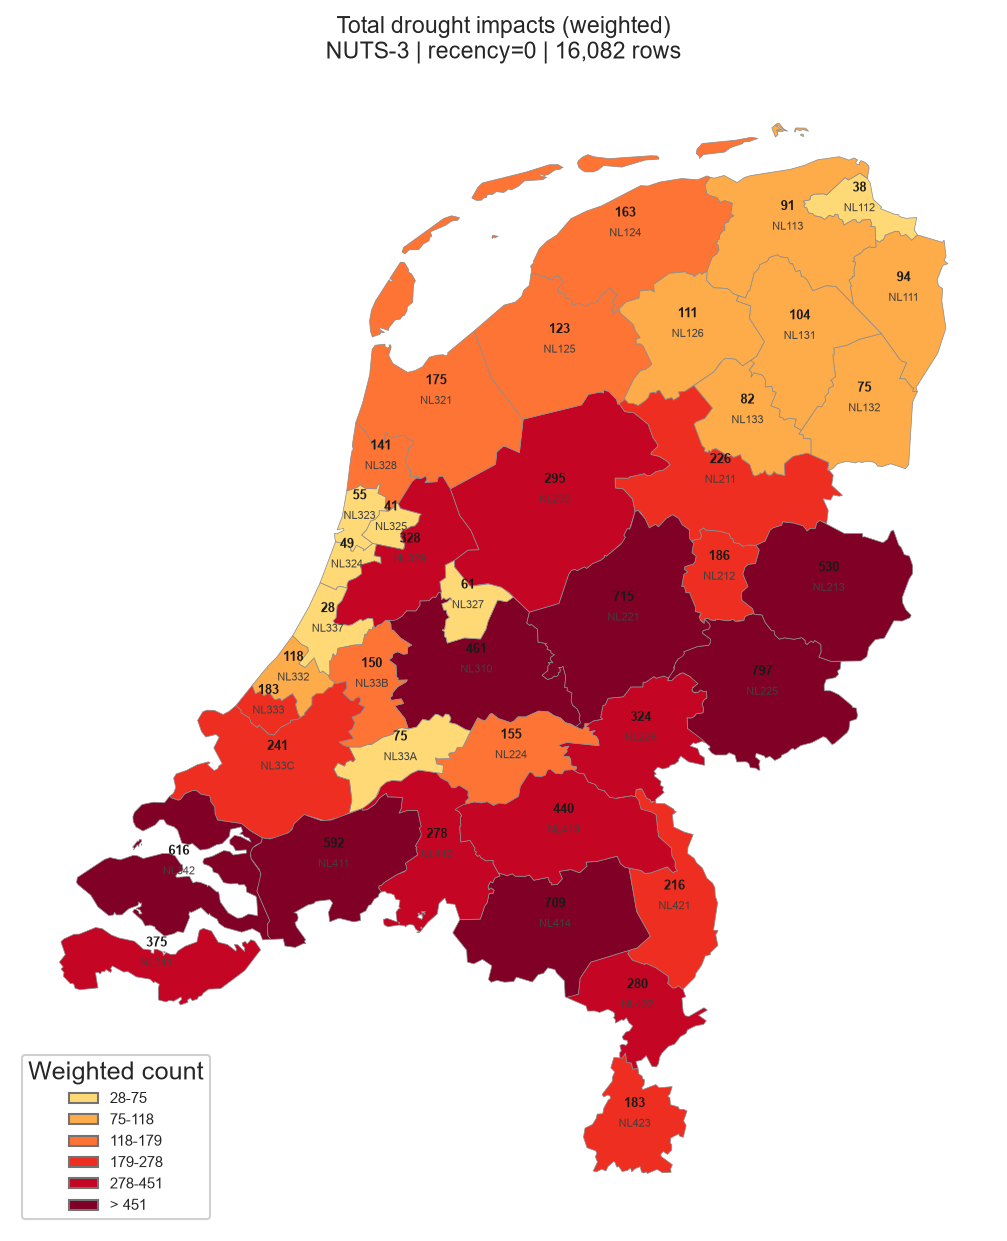

Saved fig_choropleth_nuts3.png
Top-5 NUTS-3:


,nuts3_id,nuts3_name,weighted_count
14,NL225,Achterhoek,797.250000
12,NL221,Veluwe,715.250000
36,NL414,Zuidoost-Noord-Brabant,708.964286
32,NL342,Overig Zeeland,616.250000
33,NL411,West-Noord-Brabant,591.964286


In [7]:
nuts3_totals = (
    df.groupby(["nuts3_id", "nuts3_name"], as_index=False)[COUNT_COL]
    .sum()
    .rename(columns={COUNT_COL: "weighted_count"})
    .sort_values("weighted_count", ascending=False)
)
top5 = nuts3_totals.head(5)
plot_choropleth(
    gdf3, nuts3_totals, "nuts3_id", "weighted_count",
    f"Total drought impacts (weighted)\nNUTS-3 | recency=0 | {len(df):,} rows",
    save_path=FIG_DIR / "fig_choropleth_nuts3.png",
)
print("Top-5 NUTS-3:")
display(top5)


## 6. Sector / theme distribution

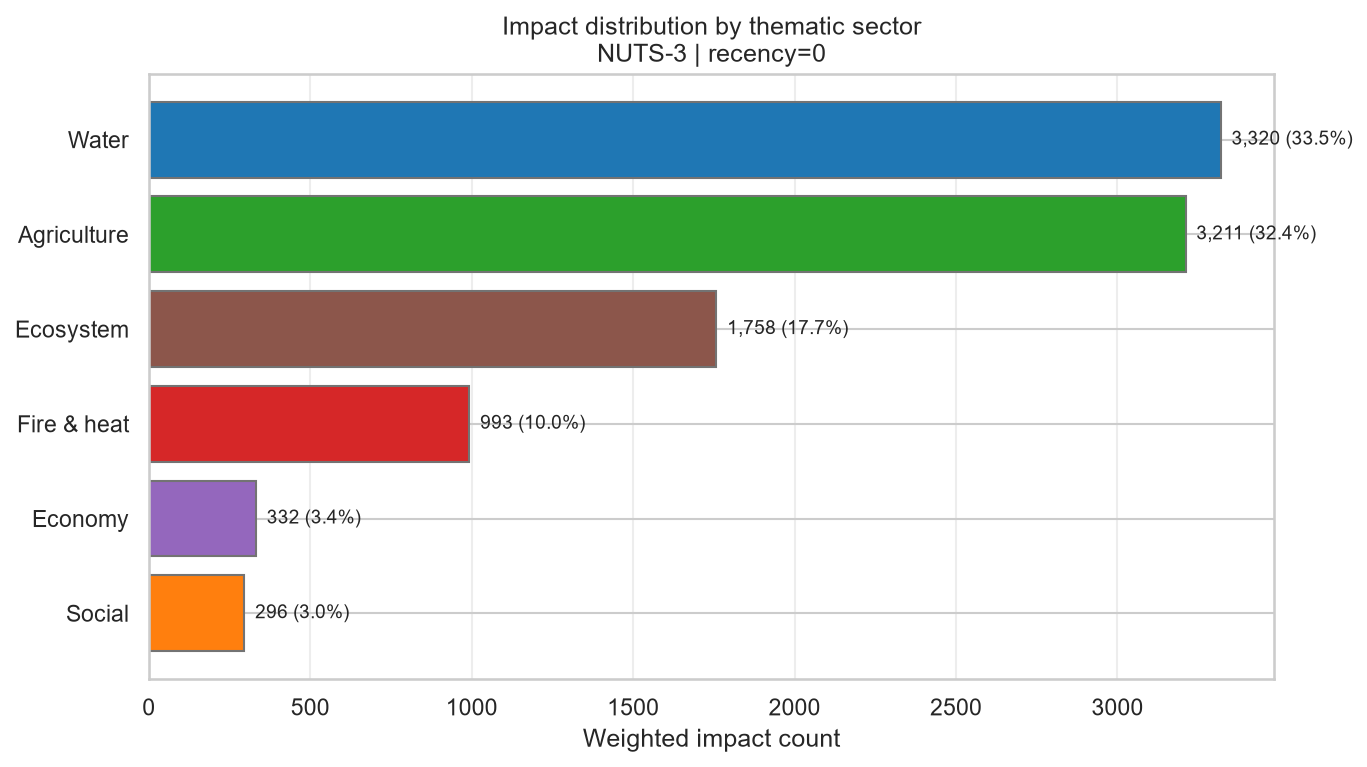

Saved fig_sector_distribution.png


,theme,theme_label,weighted_count,share_pct
1,water,Water,3320.0,33.501514
0,agriculture,Agriculture,3211.0,32.401615
2,ecosystem,Ecosystem,1758.0,17.739657
3,fire_heat,Fire & heat,993.0,10.020182
4,economy,Economy,332.0,3.350151
5,social,Social,296.0,2.986882


In [8]:
theme_rows = []
for theme in THEME_ORDER:
    classes = [c for c in CLASSIFICATION_ORDER if CLASSIFICATION_THEME[c] == theme]
    w = float(df.loc[df["classification"].isin(classes), COUNT_COL].sum())
    theme_rows.append({"theme": theme, "theme_label": THEME_LABELS[theme], "weighted_count": w})
theme_df = pd.DataFrame(theme_rows)
theme_df["share_pct"] = 100 * theme_df["weighted_count"] / theme_df["weighted_count"].sum()
theme_df = theme_df.sort_values("weighted_count", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
colors = [THEME_COLOR[t] for t in theme_df["theme"]]
ax.barh(theme_df["theme_label"], theme_df["weighted_count"], color=colors, edgecolor="0.45")
ax.set_xlabel("Weighted impact count")
ax.set_title("Impact distribution by thematic sector\nNUTS-3 | recency=0")
ax.grid(True, axis="x", alpha=0.35)
xmax = float(theme_df["weighted_count"].max())
for i, (_, row) in enumerate(theme_df.iterrows()):
    ax.text(row["weighted_count"] + xmax * 0.01, i,
            f"{row['weighted_count']:,.0f} ({row['share_pct']:.1f}%)", va="center", fontsize=9)
save_and_show(fig, FIG_DIR / "fig_sector_distribution.png")
theme_df_out = theme_df.sort_values("weighted_count", ascending=False)
display(theme_df_out)


## 7. Class distribution (all impact classifications)

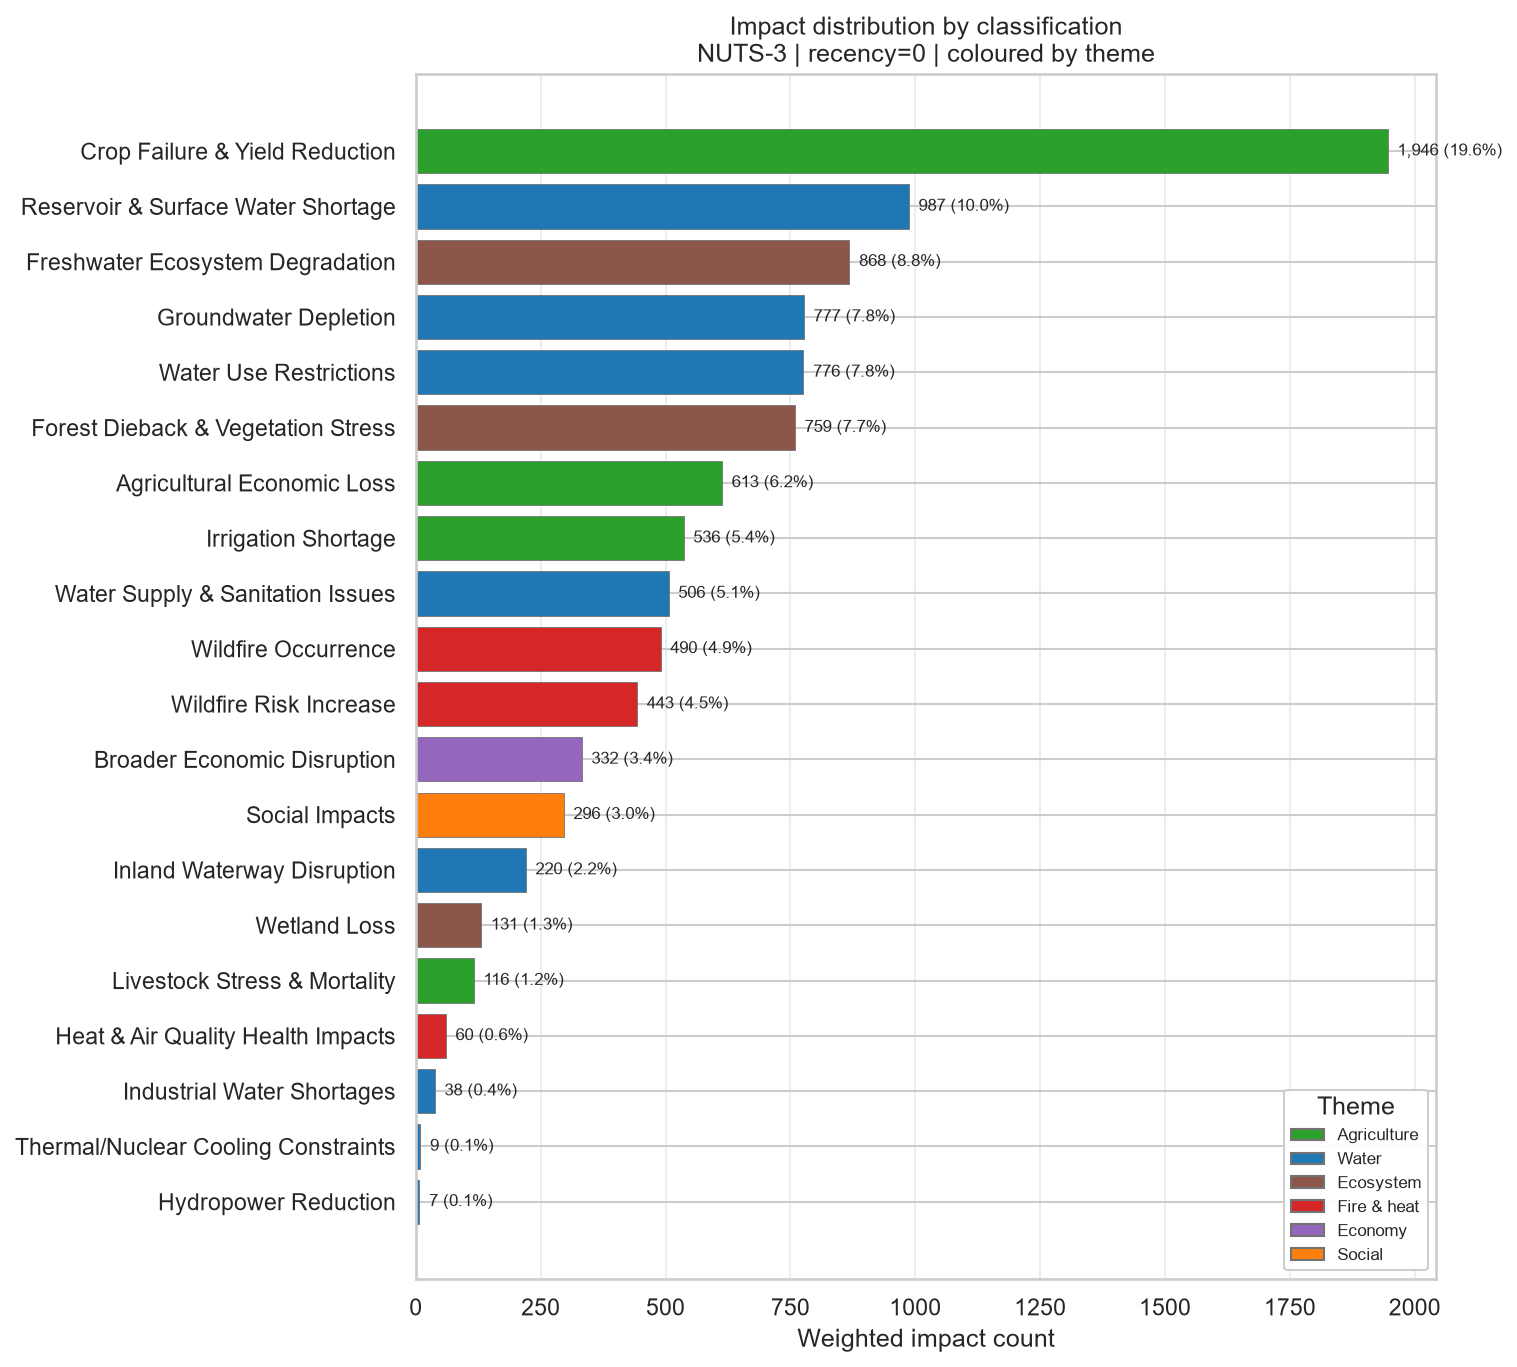

Saved fig_class_distribution.png


,classification,theme,weighted_count,share_pct
0,Crop Failure & Yield Reduction,agriculture,1946.0,19.636731
4,Reservoir & Surface Water Shortage,water,987.0,9.959637
10,Freshwater Ecosystem Degradation,ecosystem,868.0,8.758829
3,Groundwater Depletion,water,777.0,7.840565
5,Water Use Restrictions,water,776.0,7.830474
11,Forest Dieback & Vegetation Stress,ecosystem,759.0,7.658930
17,Agricultural Economic Loss,agriculture,613.0,6.185671
2,Irrigation Shortage,agriculture,536.0,5.408678
16,Water Supply & Sanitation Issues,water,506.0,5.105954
13,Wildfire Occurrence,fire_heat,490.0,4.944501


Saved classification_total_counts.csv


In [9]:
class_rows = []
for cls in CLASSIFICATION_ORDER:
    w = float(df.loc[df["classification"] == cls, COUNT_COL].sum())
    class_rows.append({
        "classification": cls,
        "theme": CLASSIFICATION_THEME[cls],
        "weighted_count": w,
    })
class_df = pd.DataFrame(class_rows)
class_df["share_pct"] = 100 * class_df["weighted_count"] / class_df["weighted_count"].sum()
class_df = class_df.sort_values("weighted_count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9), layout="constrained")
colors = [THEME_COLOR[t] for t in class_df["theme"]]
ax.barh(class_df["classification"], class_df["weighted_count"], color=colors, edgecolor="0.45", linewidth=0.4)
ax.set_xlabel("Weighted impact count")
ax.set_title("Impact distribution by classification\nNUTS-3 | recency=0 | coloured by theme")
ax.grid(True, axis="x", alpha=0.35)
xmax = float(class_df["weighted_count"].max())
for i, (_, row) in enumerate(class_df.iterrows()):
    ax.text(
        row["weighted_count"] + xmax * 0.01,
        i,
        f"{row['weighted_count']:,.0f} ({row['share_pct']:.1f}%)",
        va="center",
        fontsize=8,
    )
theme_handles = [
    Patch(facecolor=THEME_COLOR[t], edgecolor="0.45", label=THEME_LABELS[t])
    for t in THEME_ORDER
]
ax.legend(handles=theme_handles, title="Theme", loc="lower right", fontsize=8, framealpha=0.95)
save_and_show(fig, FIG_DIR / "fig_class_distribution.png")

class_df_out = class_df.sort_values("weighted_count", ascending=False)
class_df_out.to_csv(TABLE_DIR / "classification_total_counts.csv", index=False)
display(class_df_out)
print("Saved classification_total_counts.csv")


## 8. Co-occurrence — within article (primary)

Article edges: 163 | wildfire pair rank: 13 | using top_n=13


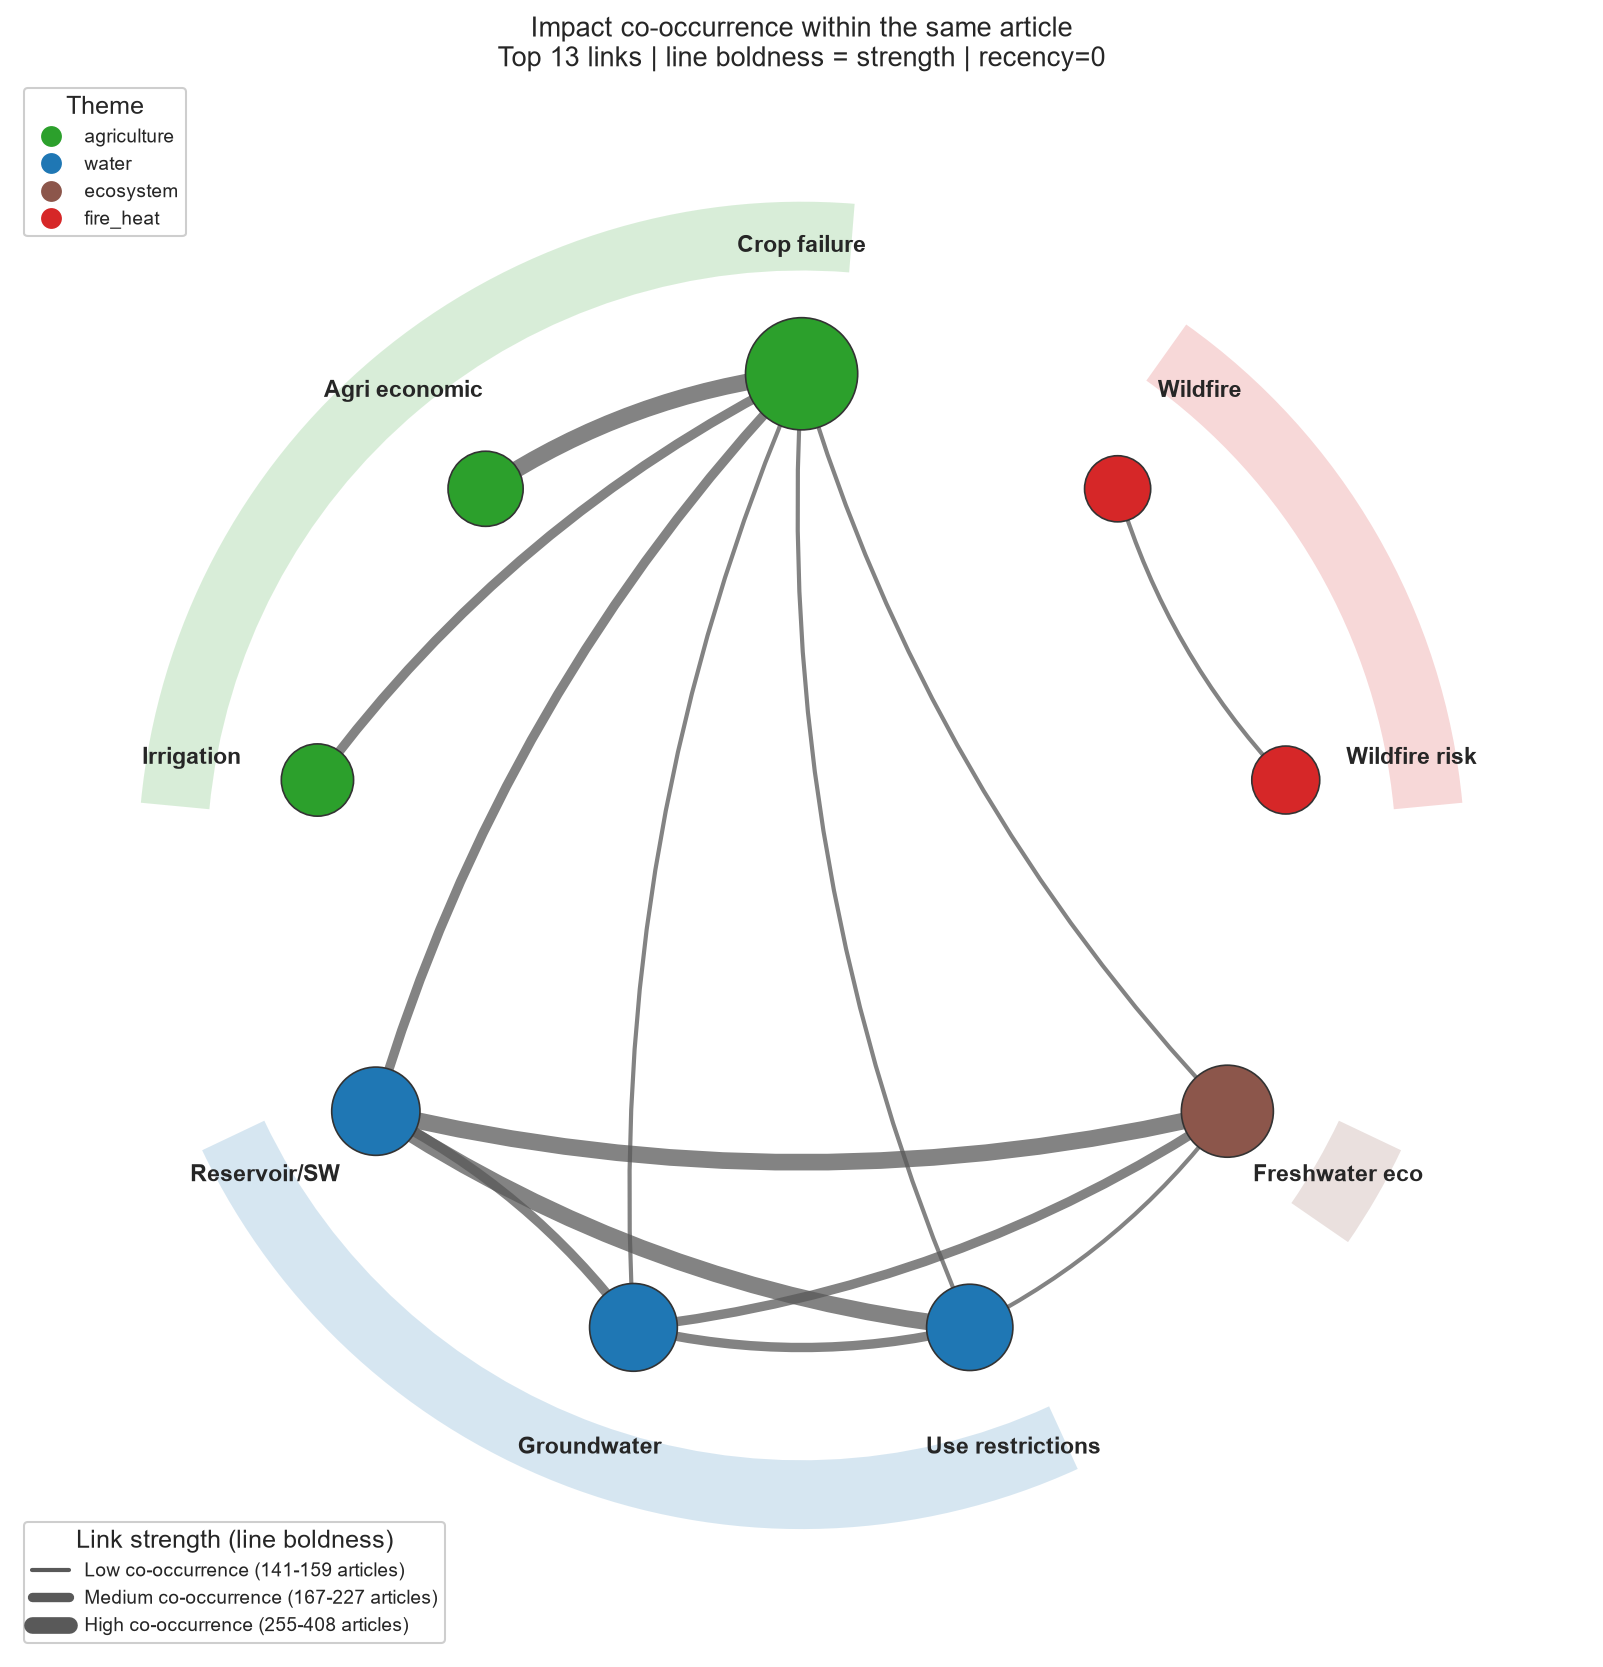

Saved fig_cooccurrence_article_theme_circular.png


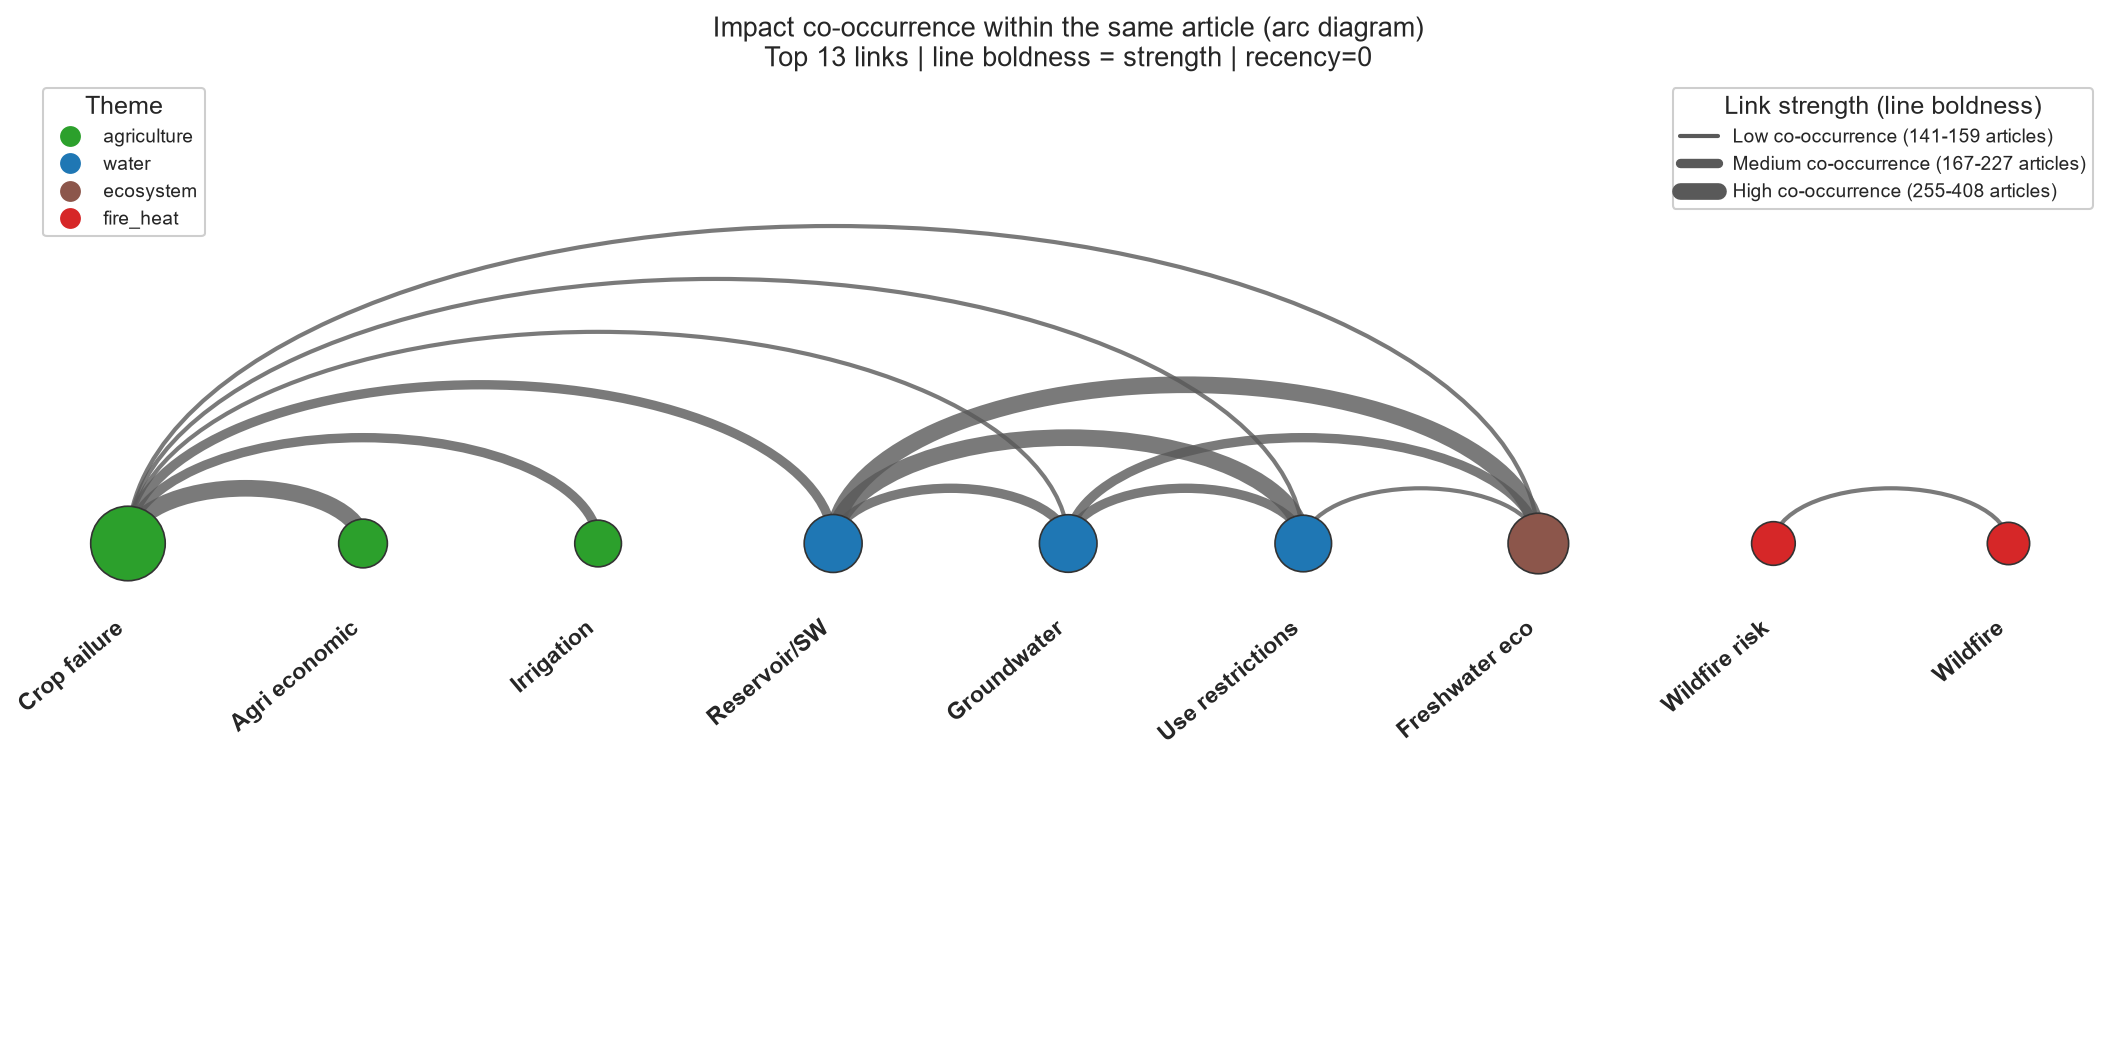

Saved fig_cooccurrence_article_arc.png


,source,target,weight
1,Agricultural Economic Loss,Crop Failure & Yield Reduction,408
37,Freshwater Ecosystem Degradation,Reservoir & Surface Water Shortage,280
30,Reservoir & Surface Water Shortage,Water Use Restrictions,255
36,Freshwater Ecosystem Degradation,Groundwater Depletion,227
11,Crop Failure & Yield Reduction,Irrigation Shortage,227
38,Groundwater Depletion,Reservoir & Surface Water Shortage,202
69,Groundwater Depletion,Water Use Restrictions,183
24,Crop Failure & Yield Reduction,Reservoir & Surface Water Shortage,167
49,Crop Failure & Yield Reduction,Groundwater Depletion,159
52,Crop Failure & Yield Reduction,Water Use Restrictions,157


In [10]:
# Article co-occurrence
grp_art = df.groupby("id")["classification"].apply(lambda s: sorted(set(s)))
pair_art: Counter = Counter()
for classes in grp_art:
    for a, b in combinations(classes, 2):
        pair_art[(a, b)] += 1

cooc_article = pd.DataFrame(
    [{"source": a, "target": b, "weight": w} for (a, b), w in pair_art.items()]
).sort_values("weight", ascending=False)
cooc_article.to_csv(TABLE_DIR / "cooccurrence_article_edges.csv", index=False)

# Ensure wildfire pair is included: take max(TOP_N, rank of wildfire pair)
wf_rank = None
for i, row in cooc_article.reset_index(drop=True).iterrows():
    if {"Wildfire Occurrence", "Wildfire Risk Increase"} <= {row["source"], row["target"]}:
        wf_rank = i + 1
        break
top_n_art = max(TOP_N_EDGES_PLOT, wf_rank or TOP_N_EDGES_PLOT)
print(f"Article edges: {len(cooc_article)} | wildfire pair rank: {wf_rank} | using top_n={top_n_art}")

node_counts_art = df["classification"].value_counts()
G_art = build_cooc_graph(cooc_article, node_counts_art, top_n=top_n_art)
draw_theme_circular(
    G_art,
    FIG_DIR / "fig_cooccurrence_article_theme_circular.png",
    f"Impact co-occurrence within the same article\n"
    f"Top {G_art.number_of_edges()} links | line boldness = strength | recency=0",
)
draw_arc_diagram(
    G_art,
    FIG_DIR / "fig_cooccurrence_article_arc.png",
    f"Impact co-occurrence within the same article (arc diagram)\n"
    f"Top {G_art.number_of_edges()} links | line boldness = strength | recency=0",
)
display(cooc_article.head(13))


## 9. Co-occurrence — NUTS-3 + month (secondary)

NUTS3+month edges: 184 | wildfire pair rank: 38 | using top_n=38


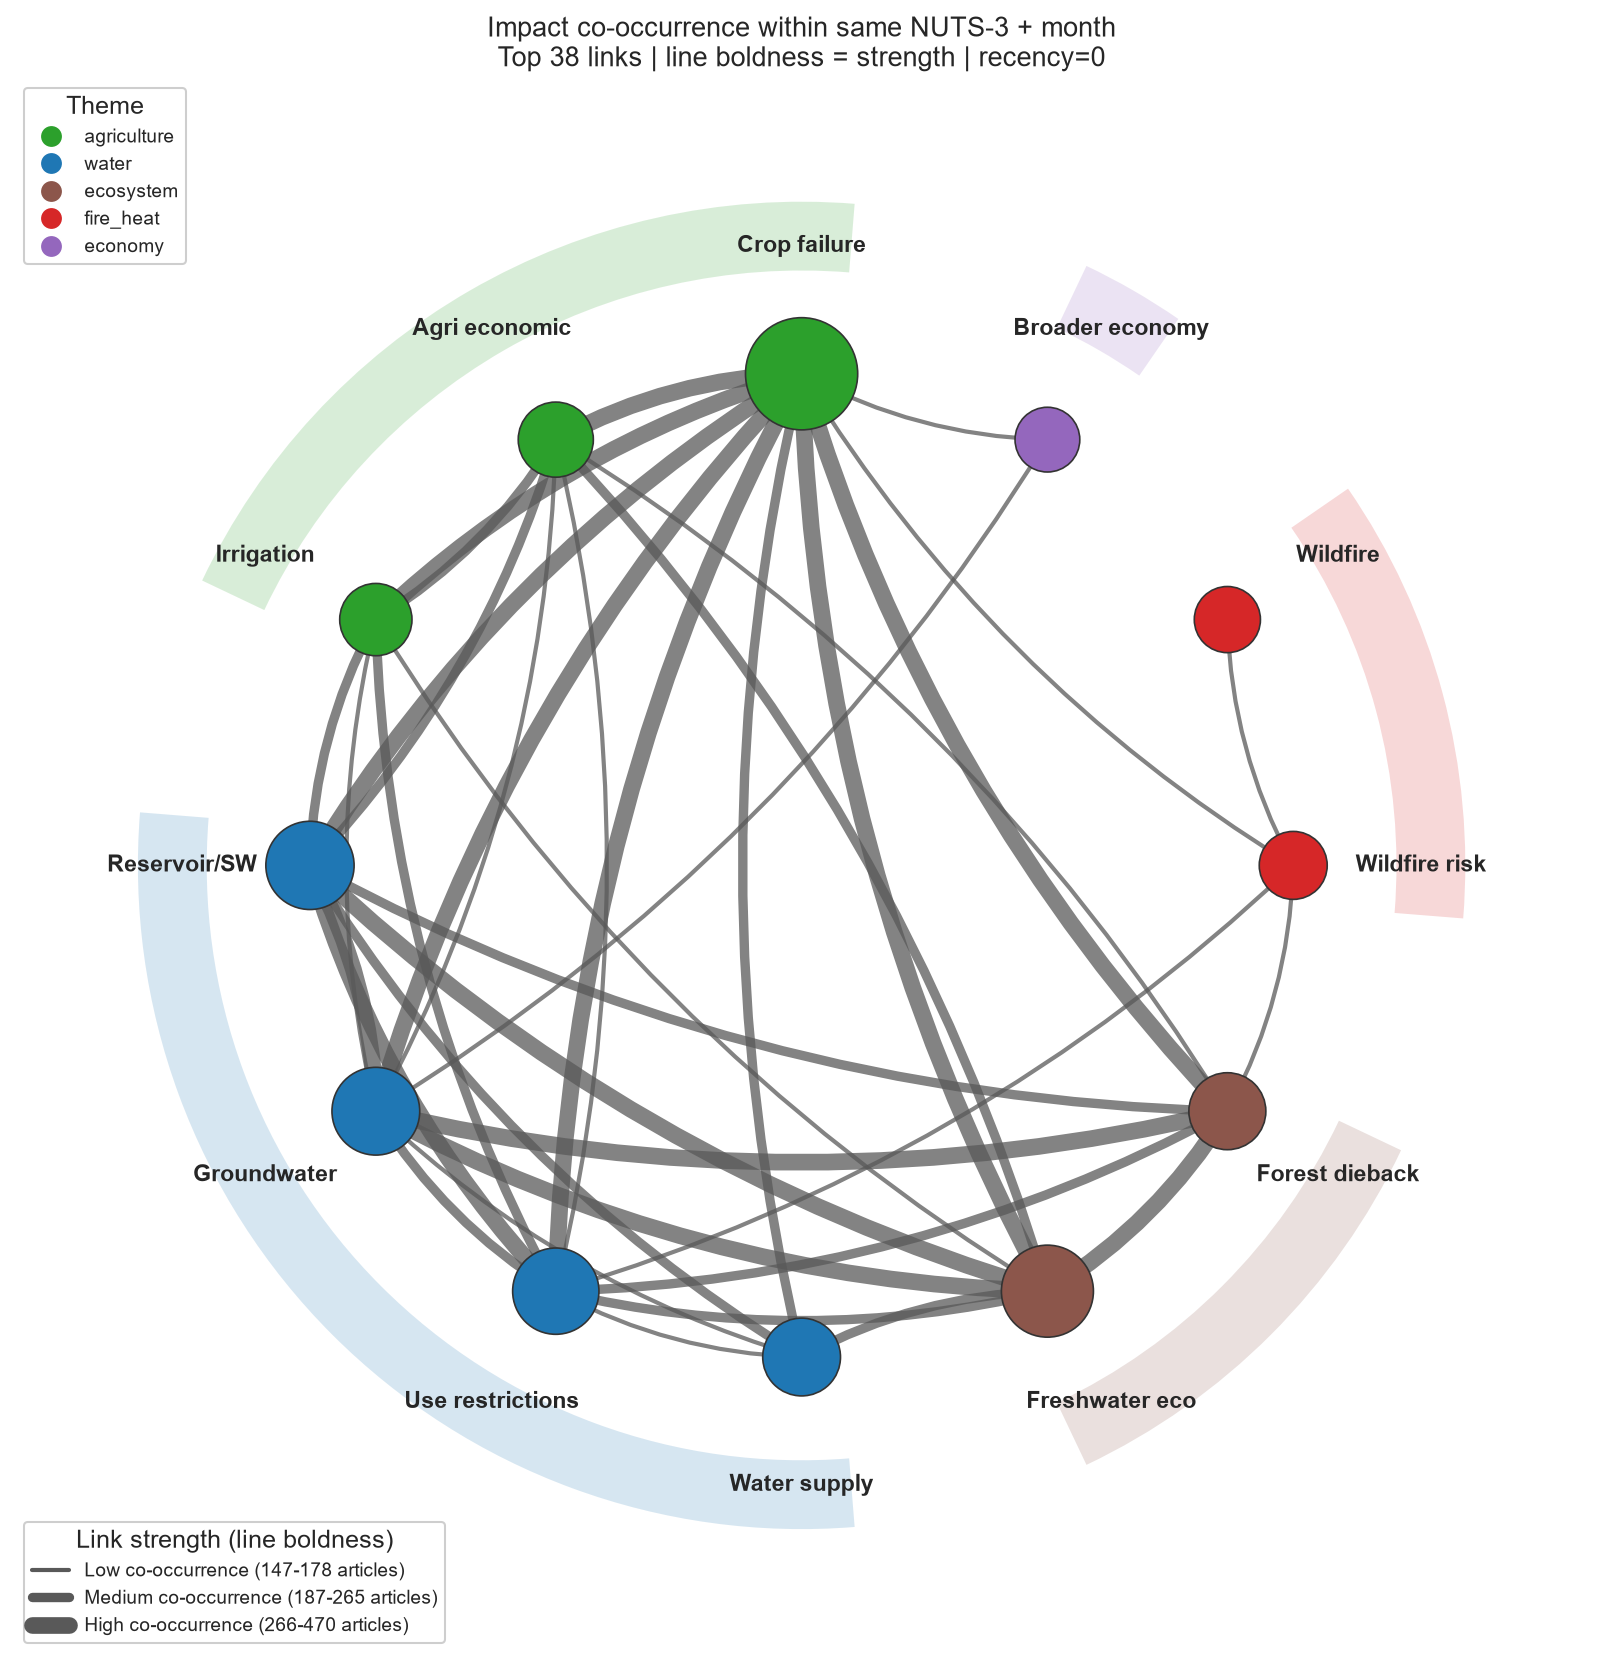

Saved fig_cooccurrence_nuts3_month_theme_circular.png


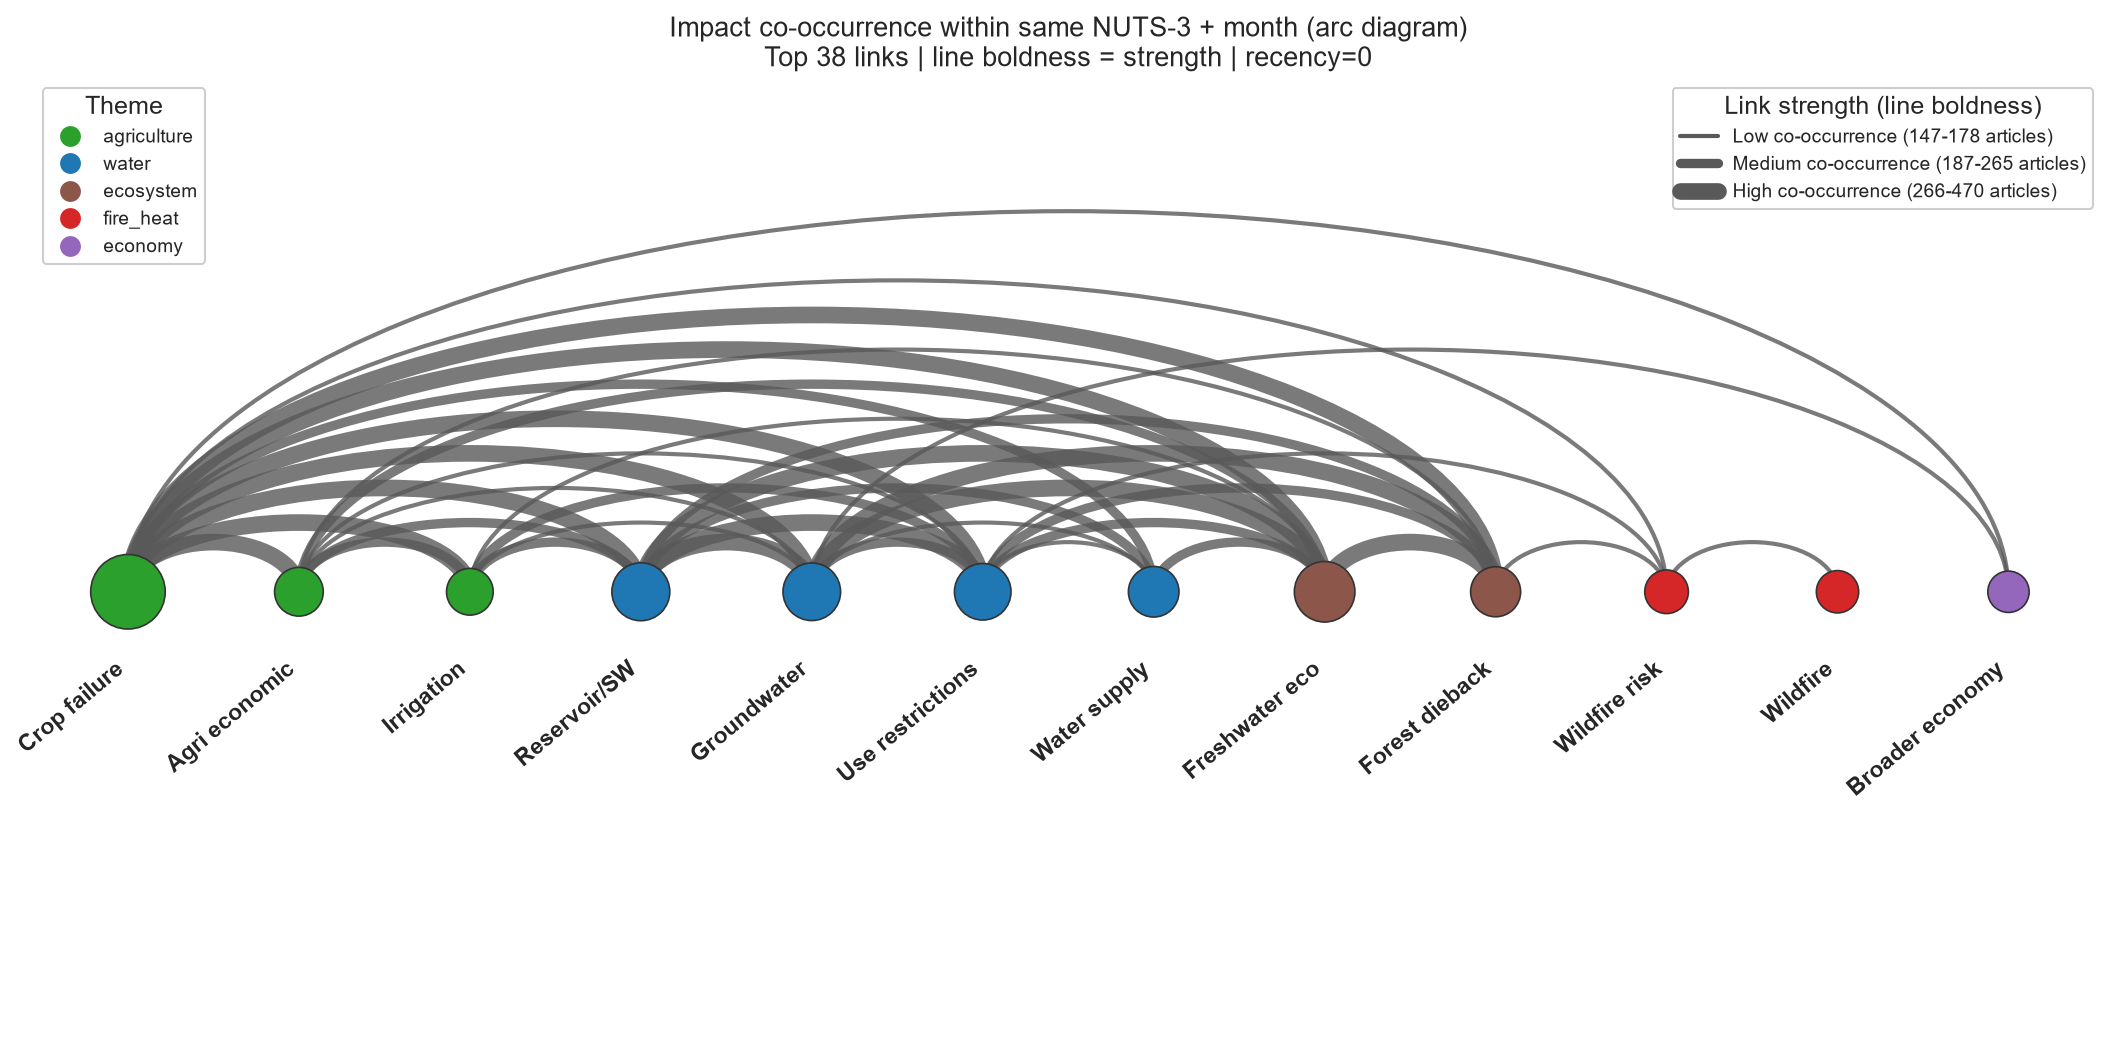

Saved fig_cooccurrence_nuts3_month_arc.png


,source,target,weight
0,Agricultural Economic Loss,Crop Failure & Yield Reduction,470
16,Crop Failure & Yield Reduction,Reservoir & Surface Water Shortage,402
13,Crop Failure & Yield Reduction,Freshwater Ecosystem Degradation,386
47,Freshwater Ecosystem Degradation,Reservoir & Surface Water Shortage,382
2,Crop Failure & Yield Reduction,Groundwater Depletion,369
6,Crop Failure & Yield Reduction,Irrigation Shortage,340
23,Freshwater Ecosystem Degradation,Groundwater Depletion,340
14,Crop Failure & Yield Reduction,Water Use Restrictions,338
33,Reservoir & Surface Water Shortage,Water Use Restrictions,307
12,Crop Failure & Yield Reduction,Forest Dieback & Vegetation Stress,304


In [11]:
# NUTS-3 + calendar month co-occurrence
grp_nm = (
    df.dropna(subset=["nuts3_id"])
    .groupby(["nuts3_id", "year_month"])["classification"]
    .apply(lambda s: sorted(set(s)))
)
pair_nm: Counter = Counter()
for classes in grp_nm:
    for a, b in combinations(classes, 2):
        pair_nm[(a, b)] += 1

cooc_nm = pd.DataFrame(
    [{"source": a, "target": b, "weight": w} for (a, b), w in pair_nm.items()]
).sort_values("weight", ascending=False)
cooc_nm.to_csv(TABLE_DIR / "cooccurrence_nuts3_month_edges.csv", index=False)

wf_rank_nm = None
for i, row in cooc_nm.reset_index(drop=True).iterrows():
    if {"Wildfire Occurrence", "Wildfire Risk Increase"} <= {row["source"], row["target"]}:
        wf_rank_nm = i + 1
        break
top_n_nm = max(TOP_N_EDGES_PLOT, wf_rank_nm or TOP_N_EDGES_PLOT)
print(f"NUTS3+month edges: {len(cooc_nm)} | wildfire pair rank: {wf_rank_nm} | using top_n={top_n_nm}")

node_counts_nm = df["classification"].value_counts()
G_nm = build_cooc_graph(cooc_nm, node_counts_nm, top_n=top_n_nm)
draw_theme_circular(
    G_nm,
    FIG_DIR / "fig_cooccurrence_nuts3_month_theme_circular.png",
    f"Impact co-occurrence within same NUTS-3 + month\n"
    f"Top {G_nm.number_of_edges()} links | line boldness = strength | recency=0",
)
draw_arc_diagram(
    G_nm,
    FIG_DIR / "fig_cooccurrence_nuts3_month_arc.png",
    f"Impact co-occurrence within same NUTS-3 + month (arc diagram)\n"
    f"Top {G_nm.number_of_edges()} links | line boldness = strength | recency=0",
)
display(cooc_nm.head(13))


## 10. Stats summary for Overleaf

In [12]:
stats_rows = [
    {"metric": "filter", "value": "nuts3 + recency_in_months==0"},
    {"metric": "n_rows", "value": len(df)},
    {"metric": "n_rows_2005_2025", "value": len(df_years)},
    {"metric": "n_articles", "value": df["id"].nunique()},
    {"metric": "early_total_2005_2017", "value": early_total},
    {"metric": "late_total_2018_2025", "value": late_total},
    {"metric": "early_mean_per_year", "value": round(early_mean, 1)},
    {"metric": "late_mean_per_year", "value": round(late_mean, 1)},
    {"metric": "count_2017", "value": jump_2017},
    {"metric": "count_2018", "value": jump_2018},
    {"metric": "peak_year", "value": int(yearly.idxmax())},
    {"metric": "peak_count", "value": int(yearly.max())},
    {"metric": "may_sep_pct", "value": round(summer_pct, 1)},
    {"metric": "jul_aug_pct", "value": round(jul_aug_pct, 1)},
    {"metric": "dec_feb_pct", "value": round(winter_pct, 1)},
]
if len(meteo_divergent):
    stats_rows.append({
        "metric": "meteo_divergent_years",
        "value": "; ".join(
            f"{int(r['year'])} (Δ={r['delta_norm']:.2f}, {r['higher']} higher)"
            for _, r in meteo_divergent.iterrows()
        ),
    })
for i, (_, r) in enumerate(top5.iterrows(), 1):
    stats_rows.append({"metric": f"nuts3_top{i}", "value": f"{r['nuts3_name']} ({r['weighted_count']:.0f})"})
for _, r in theme_df_out.iterrows():
    stats_rows.append({"metric": f"theme_{r['theme']}", "value": f"{r['weighted_count']:.0f} ({r['share_pct']:.1f}%)"})
for i, (_, r) in enumerate(class_df_out.head(5).iterrows(), 1):
    stats_rows.append({
        "metric": f"class_top{i}",
        "value": f"{r['classification']}: {r['weighted_count']:.0f} ({r['share_pct']:.1f}%)",
    })
stats_rows.append({
    "metric": "class_bottom1",
    "value": f"{class_df_out.iloc[-1]['classification']}: {class_df_out.iloc[-1]['weighted_count']:.0f} ({class_df_out.iloc[-1]['share_pct']:.1f}%)",
})
for i, (_, r) in enumerate(cooc_article.head(5).iterrows(), 1):
    stats_rows.append({
        "metric": f"article_cooc_top{i}",
        "value": f"{SHORT_LABEL.get(r['source'], r['source'])} -- {SHORT_LABEL.get(r['target'], r['target'])}: {r['weight']}",
    })
for i, (_, r) in enumerate(cooc_nm.head(5).iterrows(), 1):
    stats_rows.append({
        "metric": f"nuts3month_cooc_top{i}",
        "value": f"{SHORT_LABEL.get(r['source'], r['source'])} -- {SHORT_LABEL.get(r['target'], r['target'])}: {r['weight']}",
    })

stats = pd.DataFrame(stats_rows)
stats.to_csv(TABLE_DIR / "report_final_stats.csv", index=False)
print("=== KEY NUMBERS FOR OVERLEAF (recency=0) ===")
display(stats)


=== KEY NUMBERS FOR OVERLEAF (recency=0) ===


,metric,value
0,filter,nuts3 + recency_in_months==0
1,n_rows,16082
2,n_rows_2005_2025,15588
3,n_articles,4369
4,early_total_2005_2017,3038
5,late_total_2018_2025,12550
6,early_mean_per_year,233.7
7,late_mean_per_year,1568.8
8,count_2017,244
9,count_2018,2095


## 11. Output checklist

In [13]:
expected_figures = [
    "fig_yearly_volume.png",
    "fig_meteo_comparison.png",
    "fig_monthly_seasonality.png",
    "fig_choropleth_nuts3.png",
    "fig_sector_distribution.png",
    "fig_class_distribution.png",
    "fig_cooccurrence_article_theme_circular.png",
    "fig_cooccurrence_article_arc.png",
    "fig_cooccurrence_nuts3_month_theme_circular.png",
    "fig_cooccurrence_nuts3_month_arc.png",
]
expected_tables = [
    "classification_total_counts.csv",
    "report_final_stats.csv",
    "cooccurrence_article_edges.csv",
    "cooccurrence_nuts3_month_edges.csv",
]

fig_existing = {p.name for p in FIG_DIR.iterdir() if p.is_file()} if FIG_DIR.exists() else set()
tab_existing = {p.name for p in TABLE_DIR.iterdir() if p.is_file()} if TABLE_DIR.exists() else set()

print("Figures:")
for f in expected_figures:
    print(f"  [{'OK' if f in fig_existing else 'MISSING'}] {f}")
print("Tables:")
for f in expected_tables:
    print(f"  [{'OK' if f in tab_existing else 'MISSING'}] {f}")

missing = (
    [f for f in expected_figures if f not in fig_existing]
    + [f for f in expected_tables if f not in tab_existing]
)
if missing:
    raise SystemExit(f"Missing: {missing}")
print(f"\nAll {len(expected_figures)} figures in {FIG_DIR}")
print(f"All {len(expected_tables)} tables in {TABLE_DIR}")


Figures:
  [OK] fig_yearly_volume.png
  [OK] fig_meteo_comparison.png
  [OK] fig_monthly_seasonality.png
  [OK] fig_choropleth_nuts3.png
  [OK] fig_sector_distribution.png
  [OK] fig_class_distribution.png
  [OK] fig_cooccurrence_article_theme_circular.png
  [OK] fig_cooccurrence_article_arc.png
  [OK] fig_cooccurrence_nuts3_month_theme_circular.png
  [OK] fig_cooccurrence_nuts3_month_arc.png
Tables:
  [OK] classification_total_counts.csv
  [OK] report_final_stats.csv
  [OK] cooccurrence_article_edges.csv
  [OK] cooccurrence_nuts3_month_edges.csv

All 10 figures in C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\08_exploratory_data_analysis\results\figures
All 4 tables in C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\08_exploratory_data_analysis\results\tables


## 12. Figure gallery (audit)

Reload saved PNGs from `figures/` so you can visually check finals without re-running the heavy plot cells.


fig_yearly_volume.png


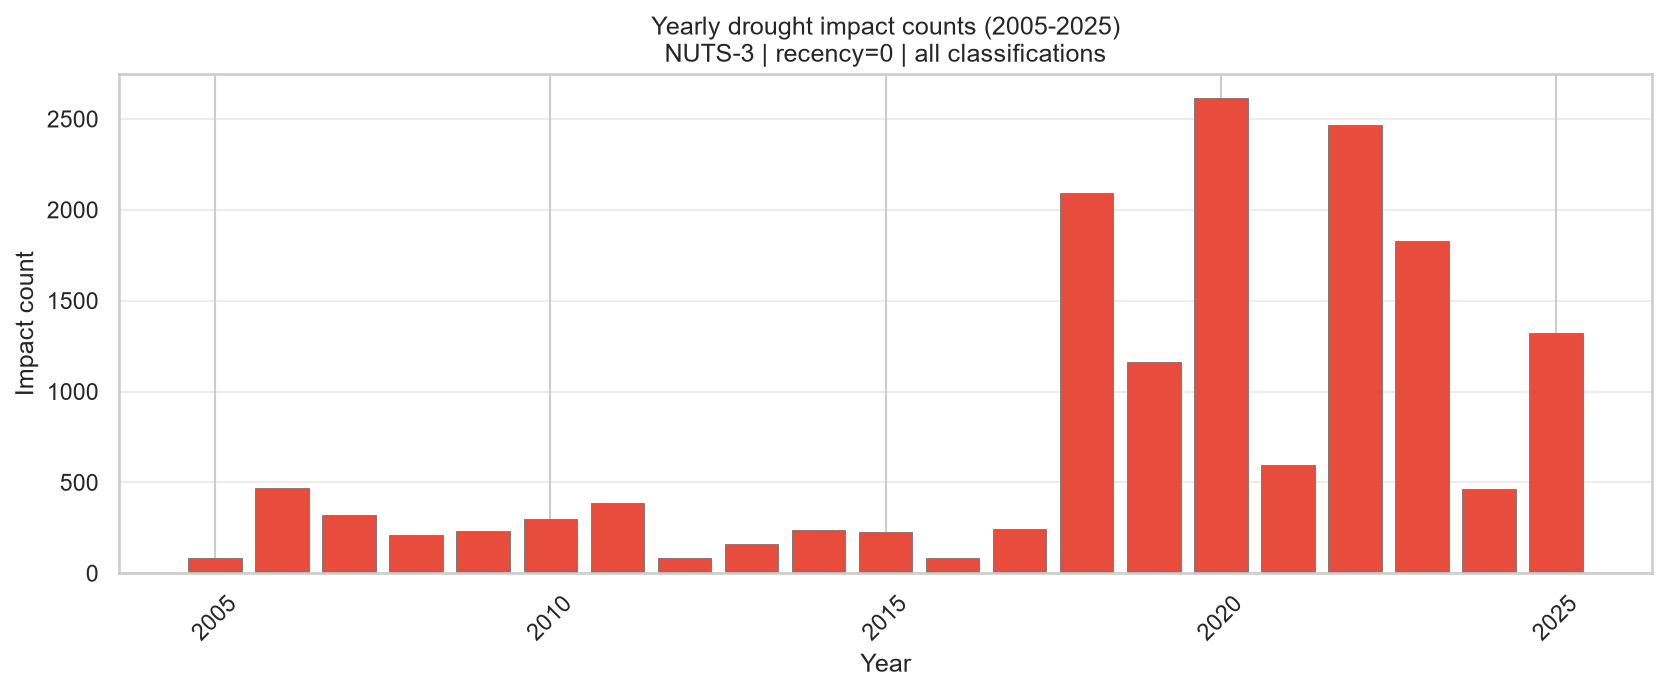

fig_meteo_comparison.png


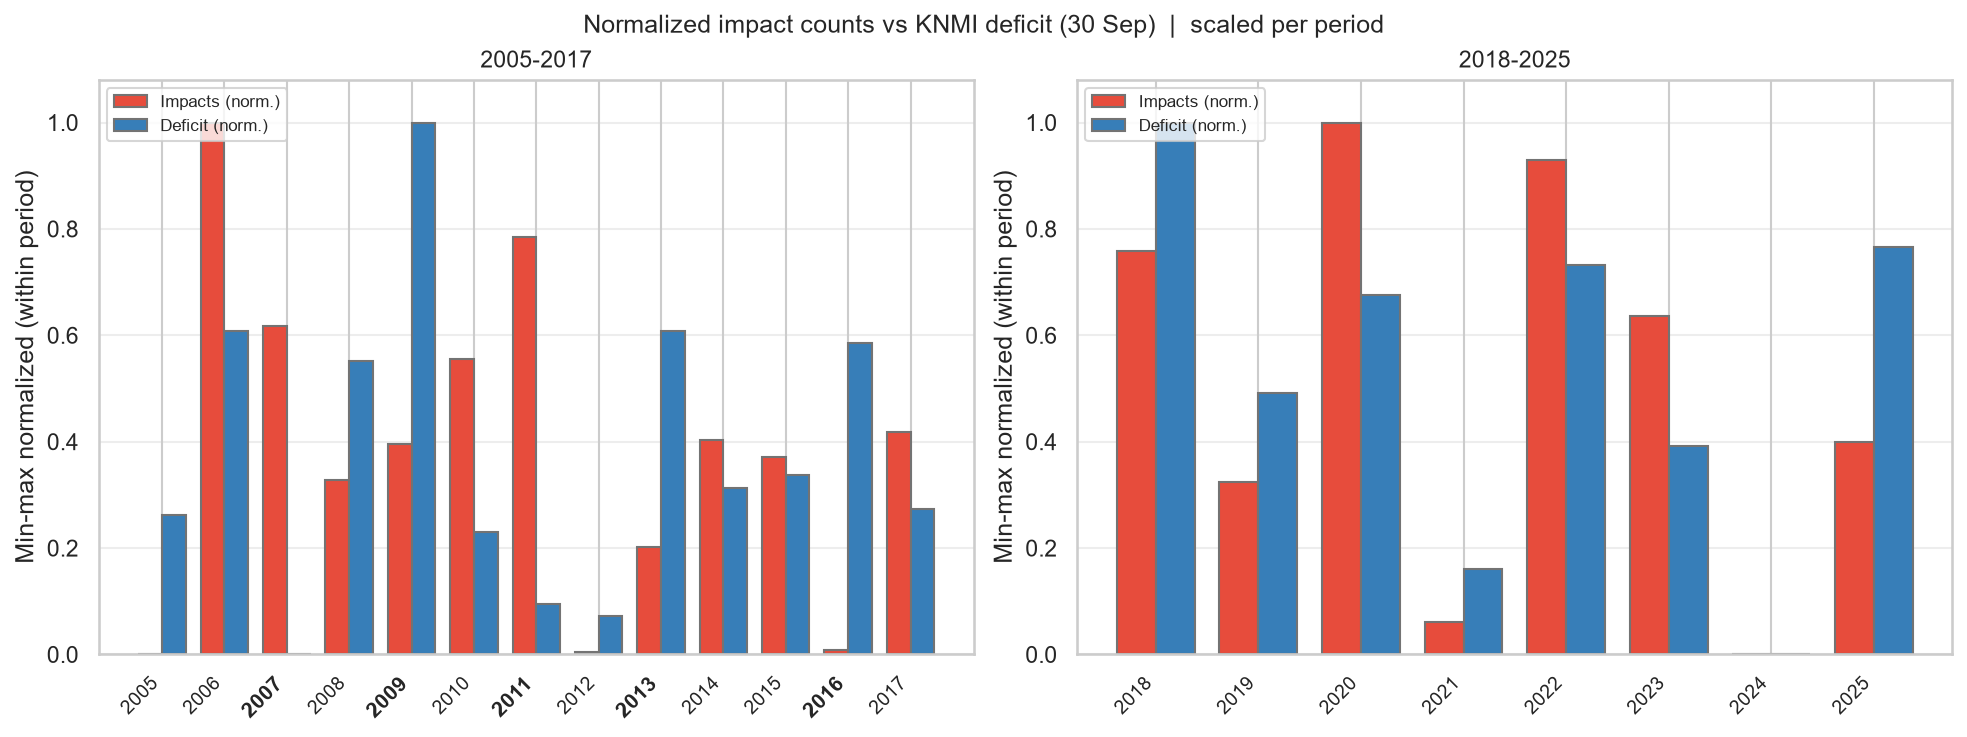

fig_monthly_seasonality.png


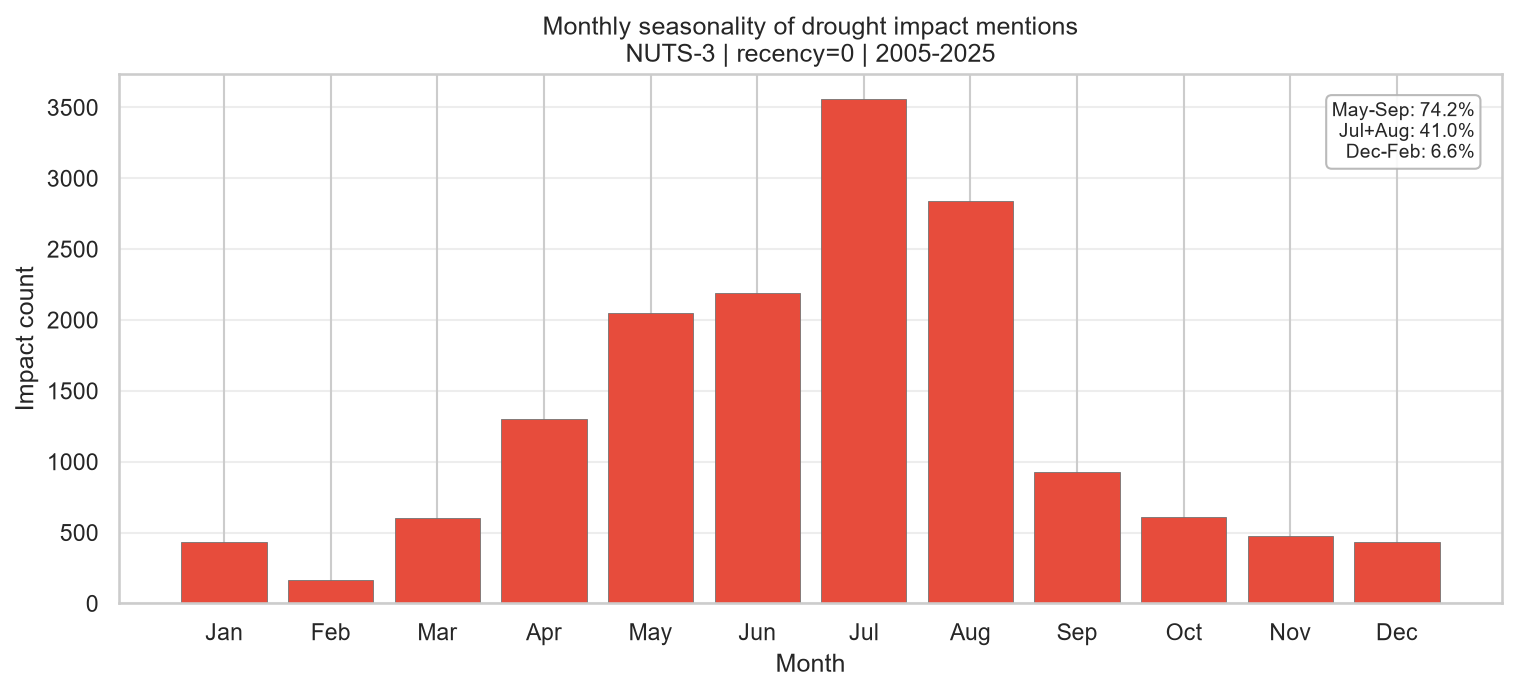

fig_choropleth_nuts3.png


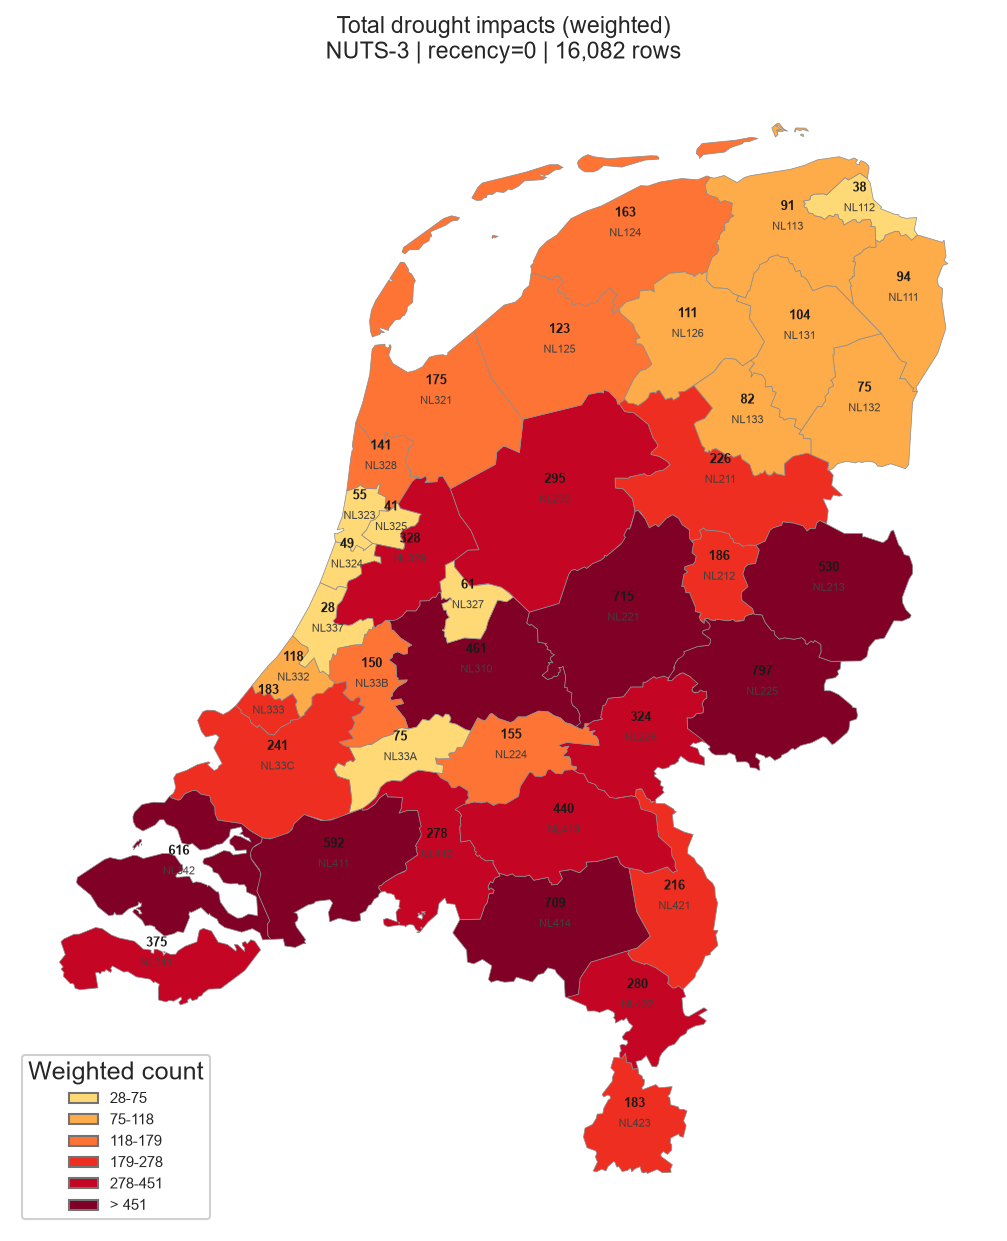

fig_sector_distribution.png


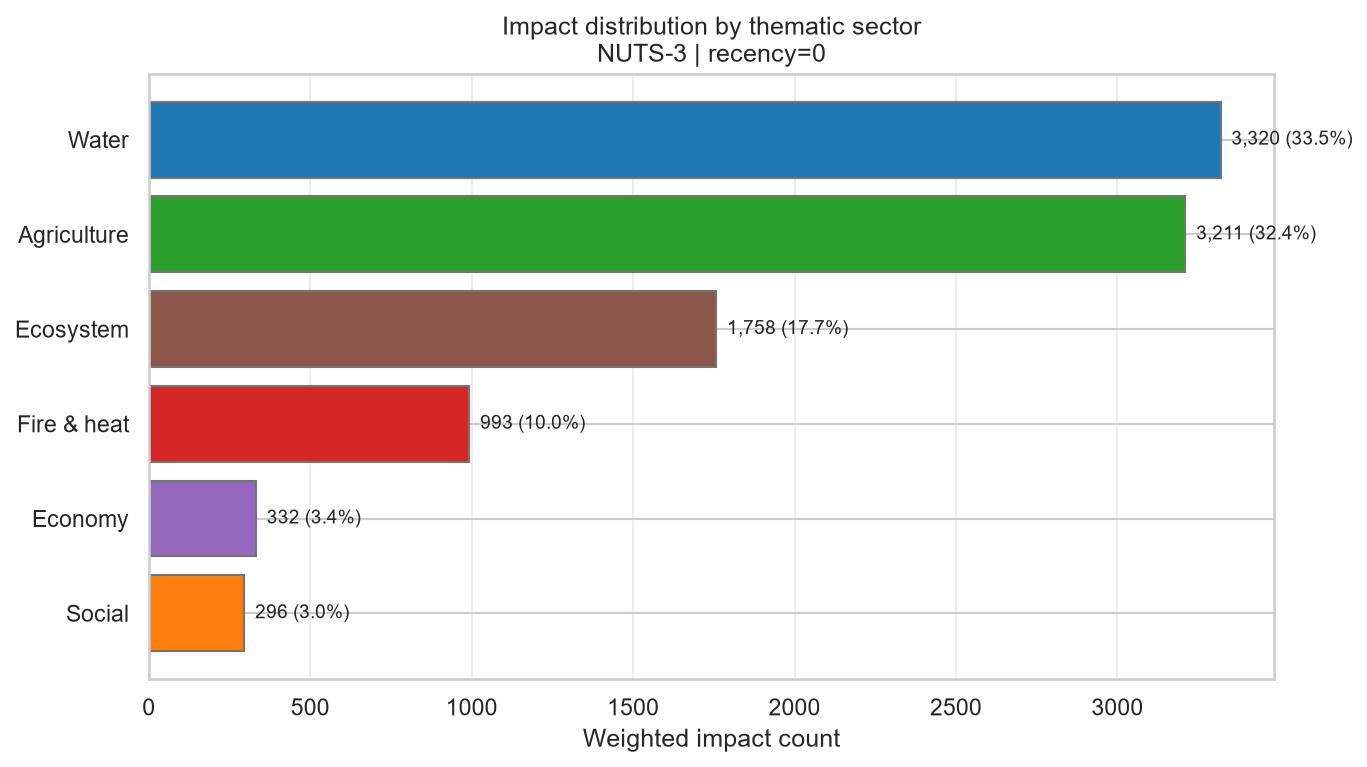

fig_class_distribution.png


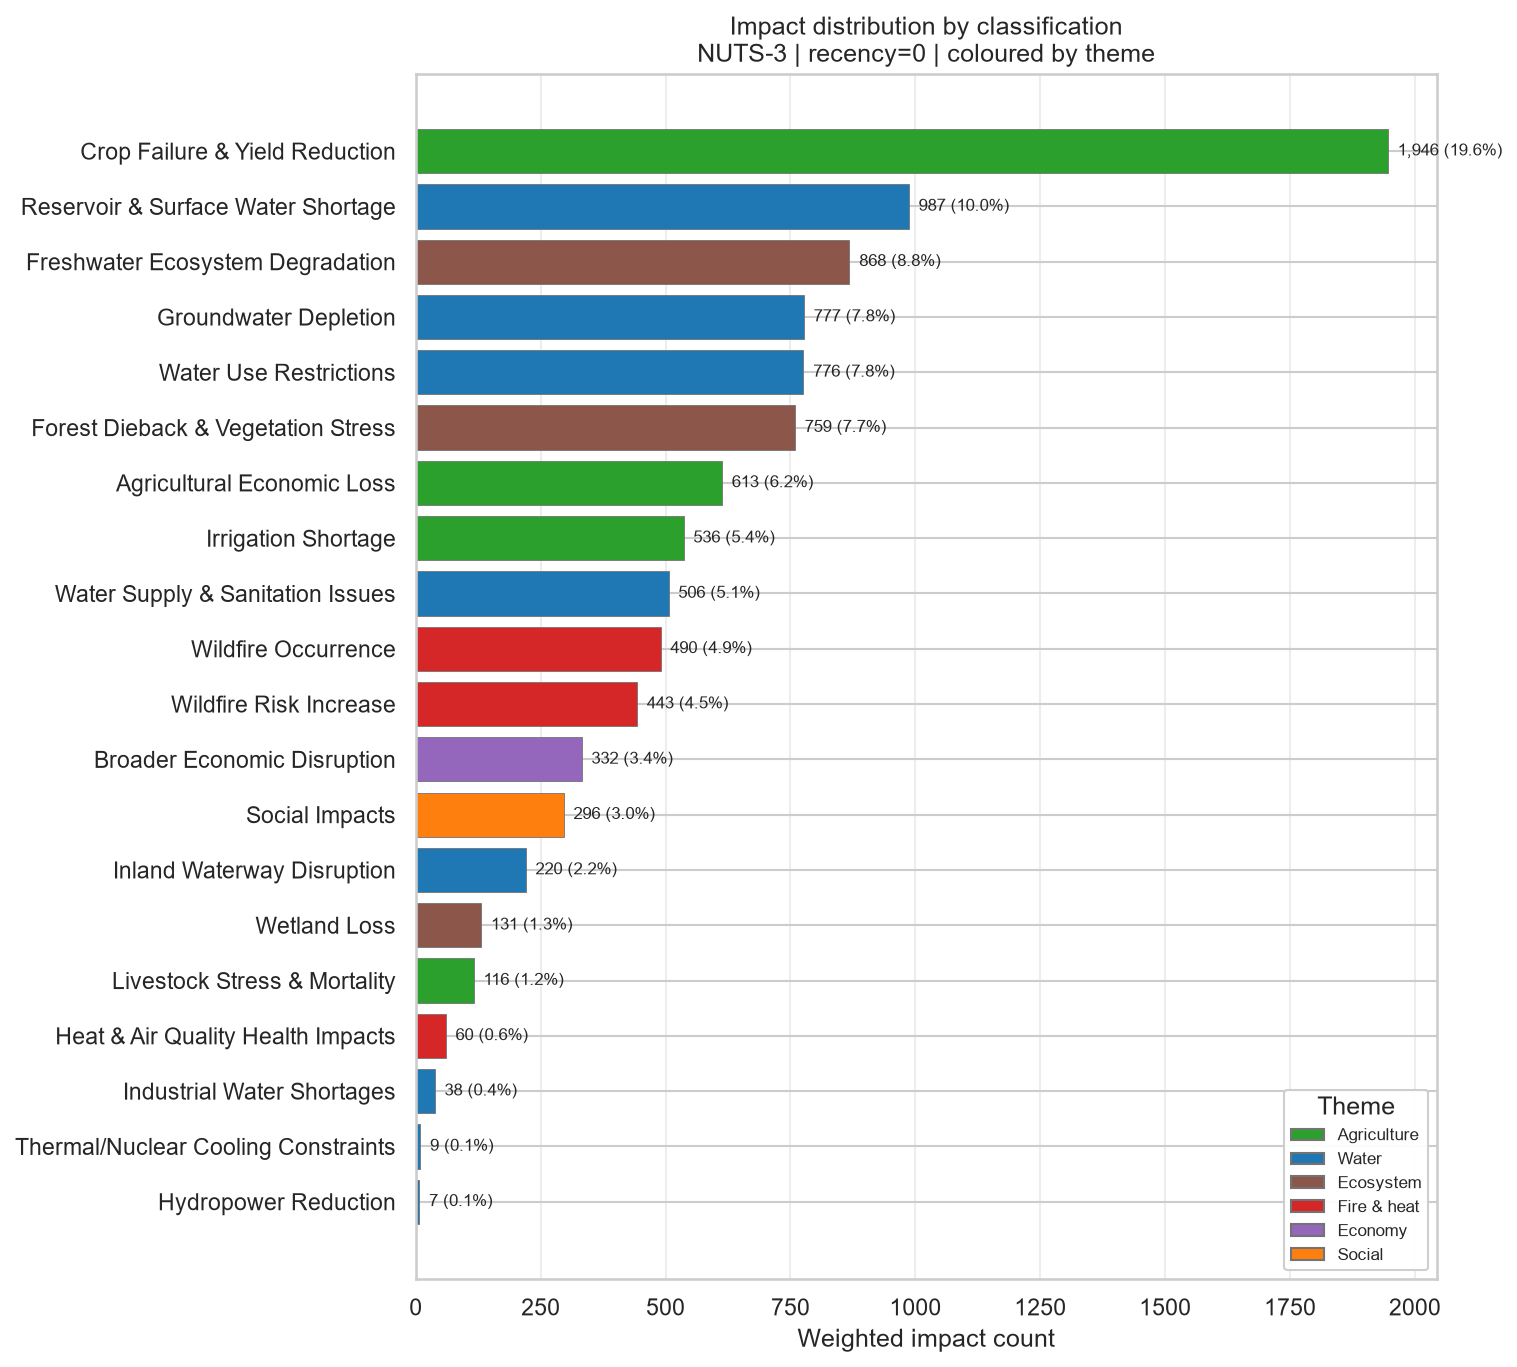

fig_cooccurrence_article_theme_circular.png


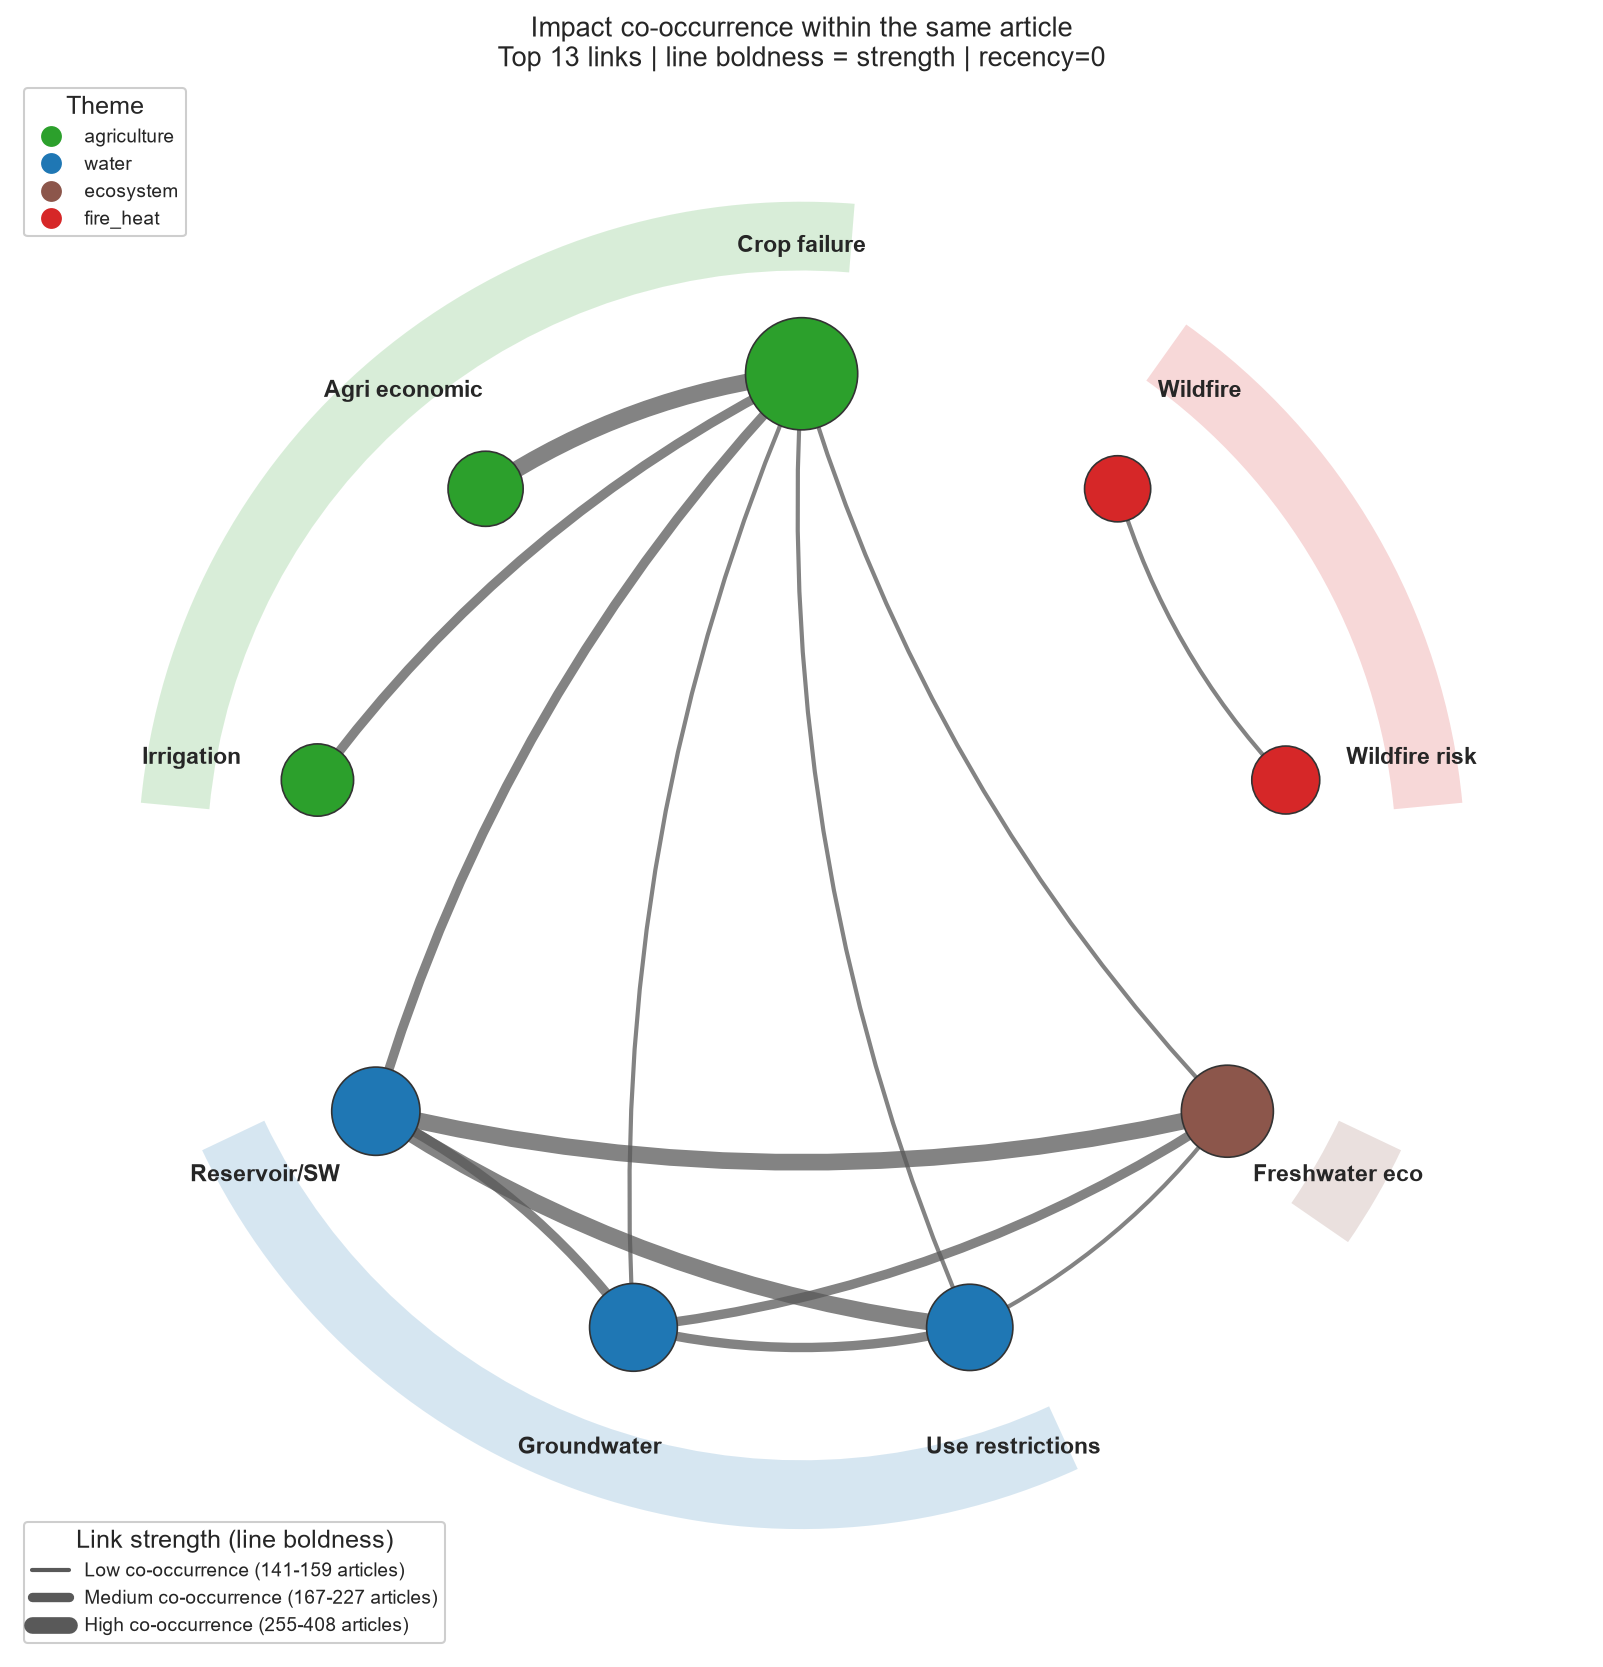

fig_cooccurrence_article_arc.png


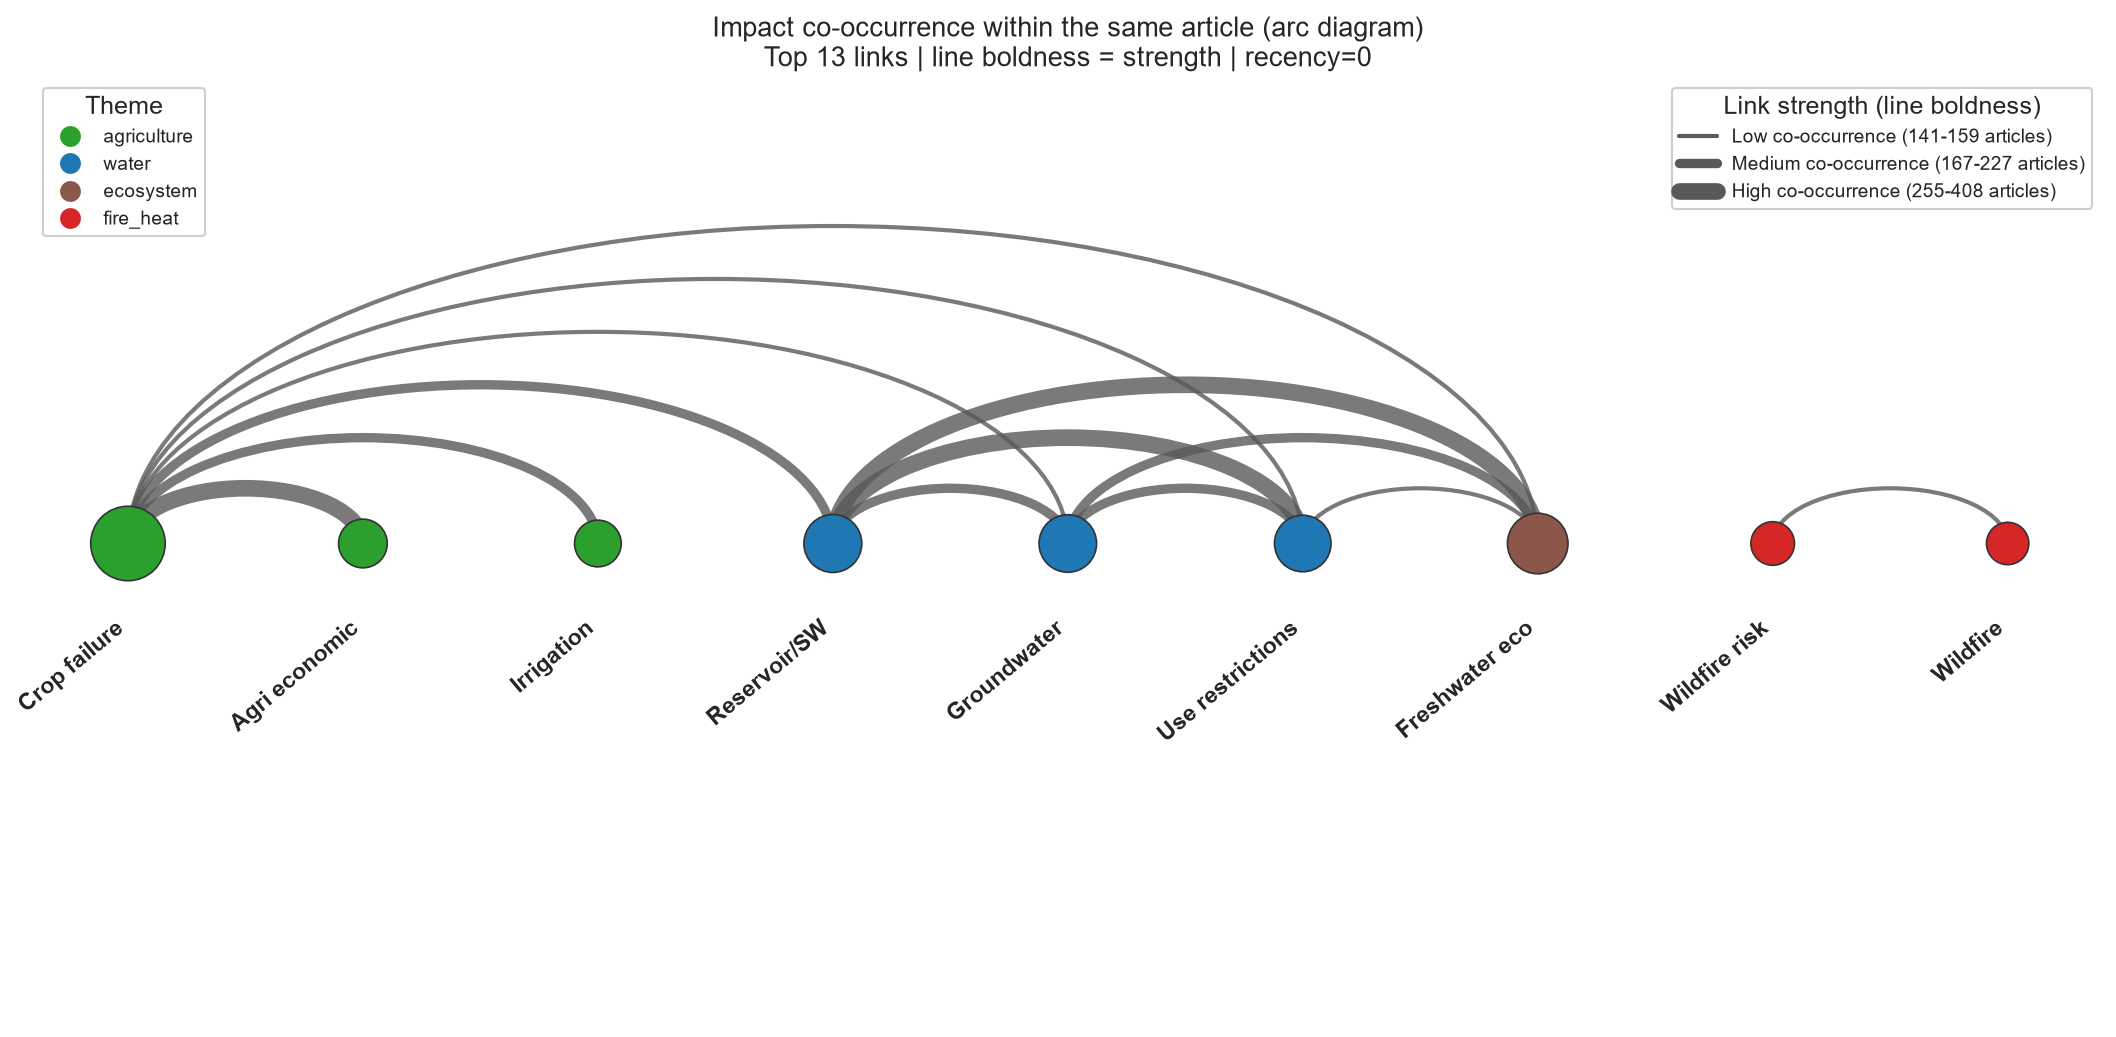

fig_cooccurrence_nuts3_month_theme_circular.png


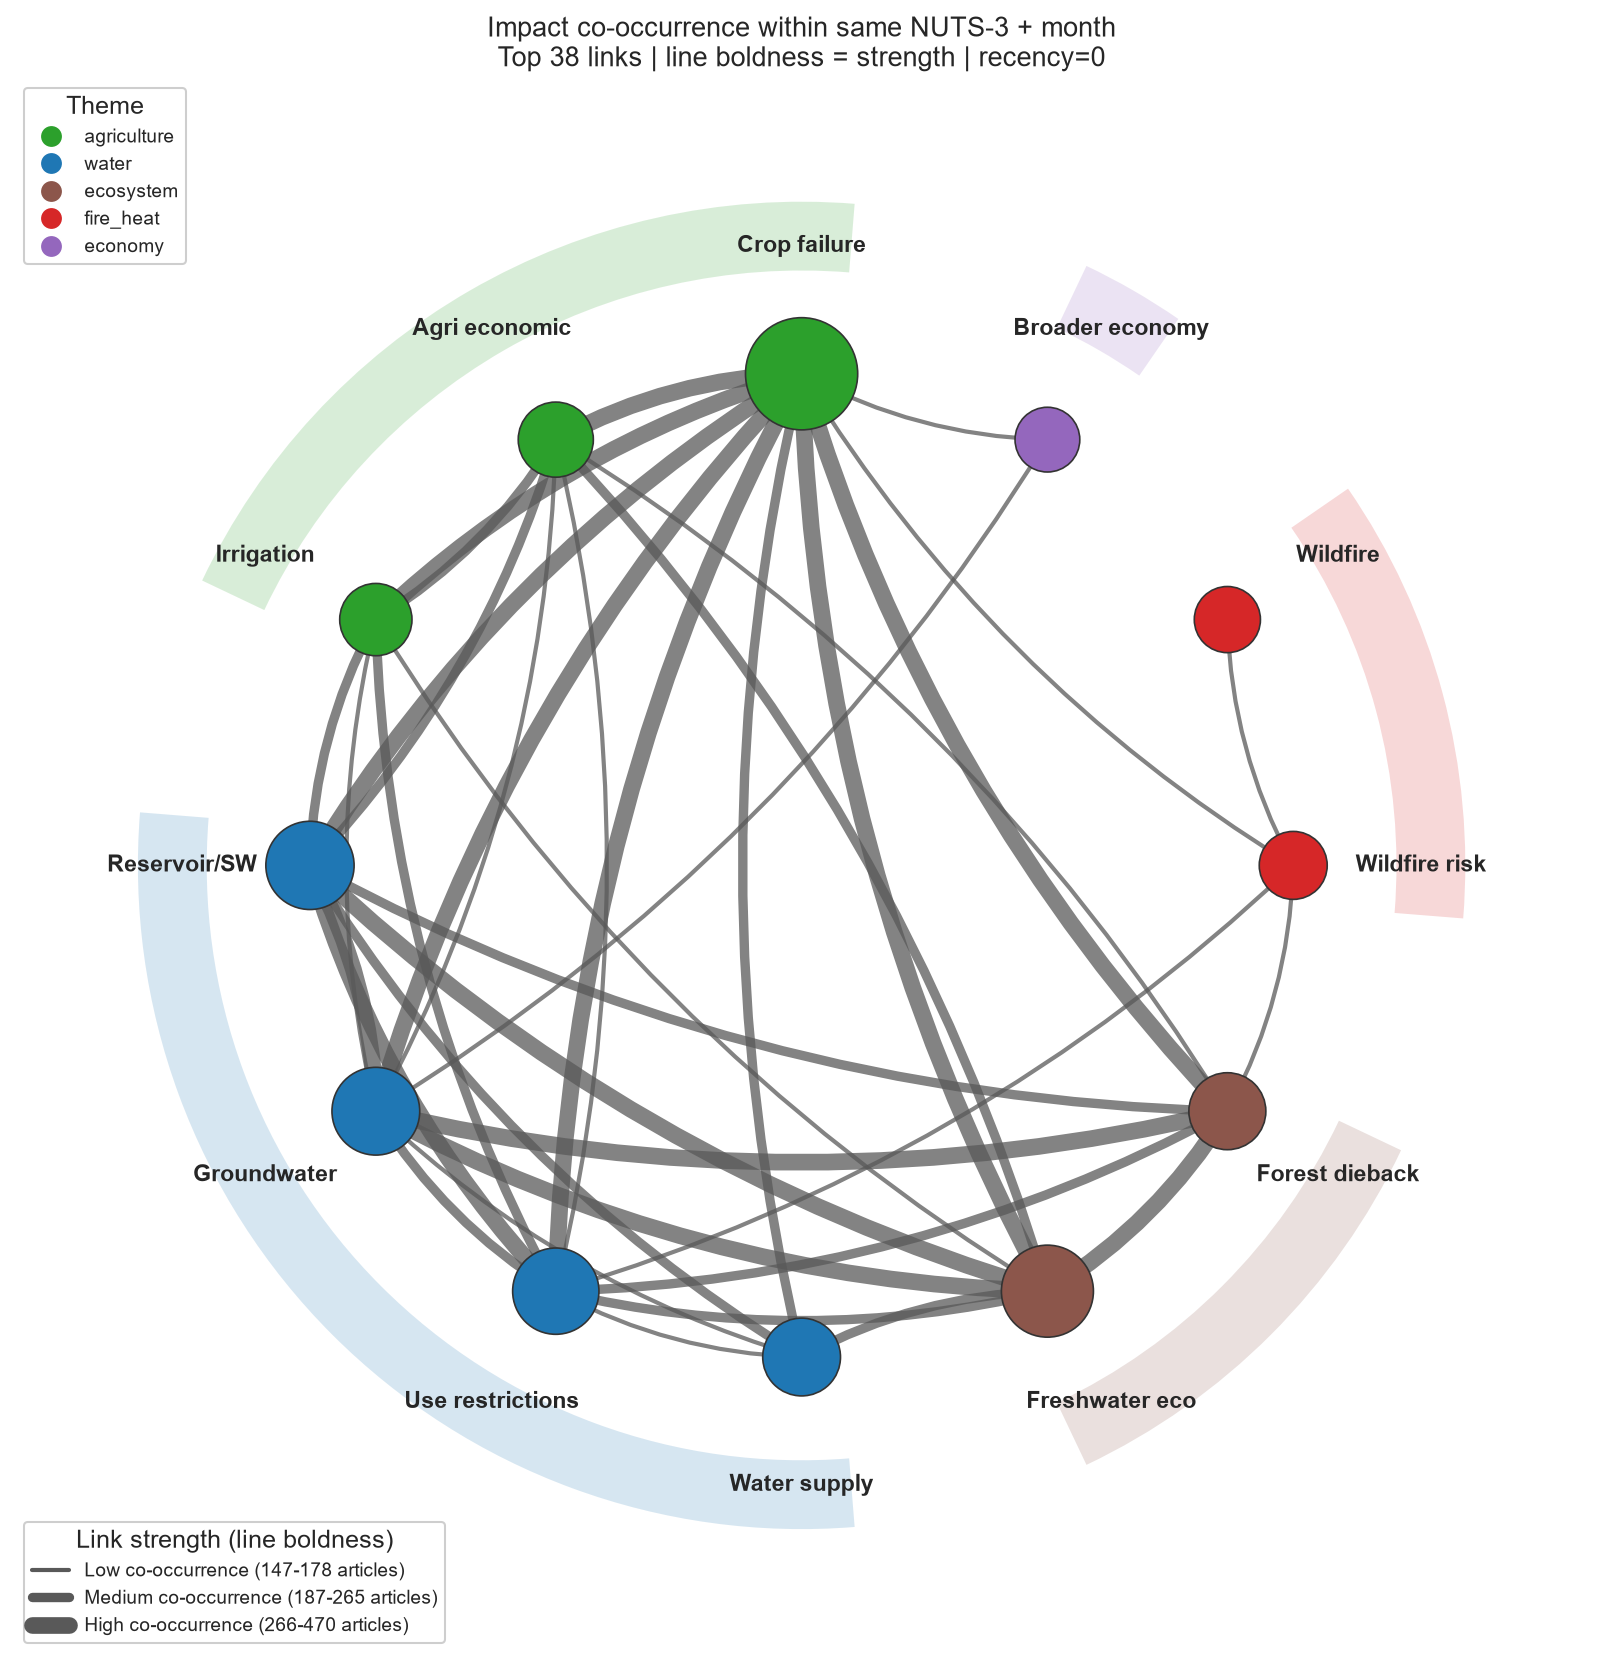

fig_cooccurrence_nuts3_month_arc.png


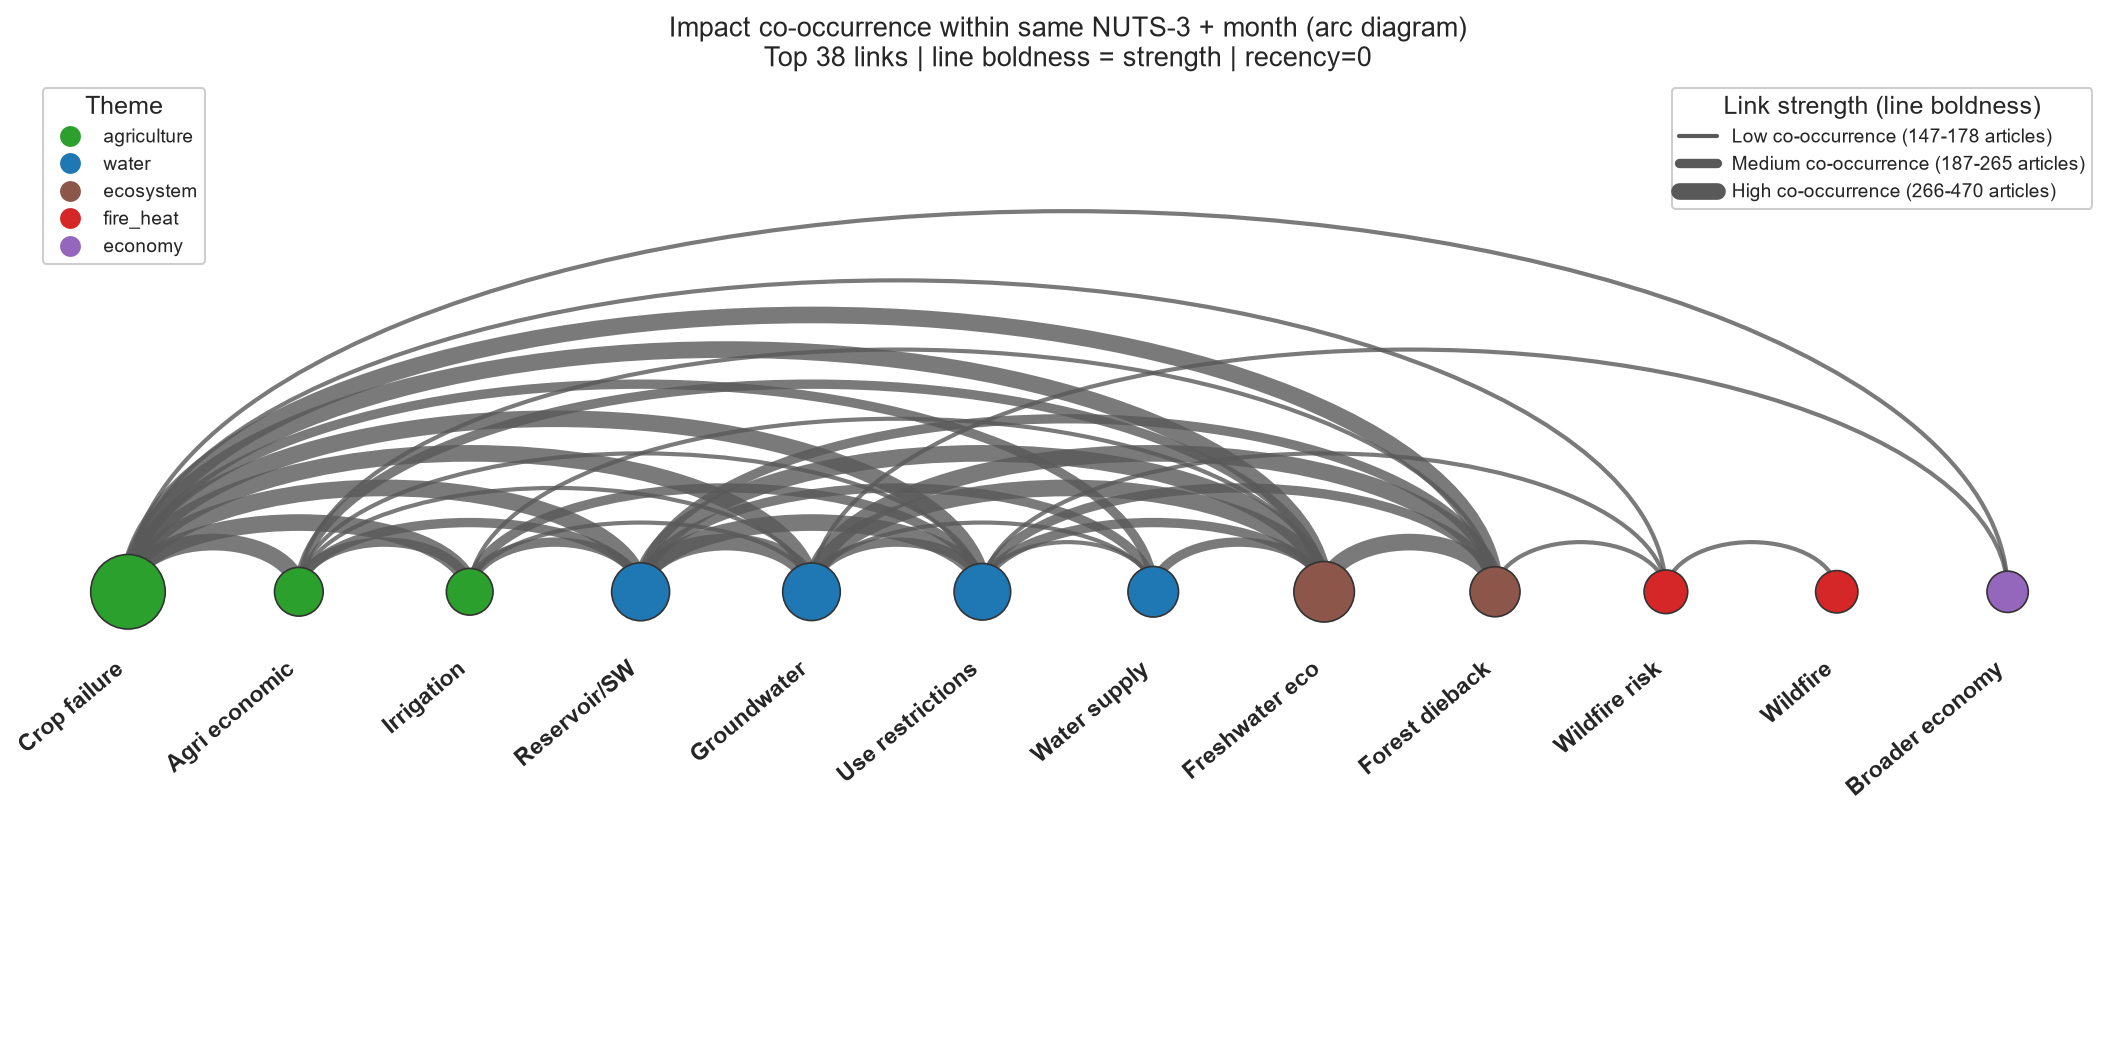

In [14]:
for name in expected_figures:
    path = FIG_DIR / name
    print(name)
    display(Image(filename=str(path)))
